In [1]:
import os
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torch.utils.data import Subset
import torch.optim as optim
import torch.nn.functional as F

In [2]:
torch.cuda.is_available()
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)
torch.cuda.device_count() # returns 1 in my case


if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)} is available.")
else:
    print("No GPU available. Training will run on CPU.")

cuda:0
GPU: NVIDIA RTX A6000 is available.


In [3]:
# === CONFIG ===

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
# === HELPERS ===
def collate_fn(batch):
    streams, labels = zip(*batch)
    streams = list(zip(*streams))
    streams = [torch.stack(s) for s in streams]
    labels = torch.tensor(labels)
    return streams, labels

def compute_class_weights(labels, device):
    counter = Counter(labels)
    total = sum(counter.values())
    weights = [np.log(total / (counter[i] + 1)) for i in range(len(counter))]
    return torch.tensor(weights, dtype=torch.float).to(device)

def print_model_info(model):
    print("Model Architecture:")
    print(model)
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Total parameters: {total_params:,}")

def plot_loss_curve(train_losses, val_losses):
    epochs = range(len(train_losses))
    plt.figure(figsize=(10, 5))
    plt.plot(epochs, train_losses, label='Train Loss', color='blue')
    plt.plot(epochs, val_losses, label='Val Loss', color='orange')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training vs Validation Loss')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_accuracy_curve(train_acc, val_acc):
    epochs = range(len(train_acc))
    plt.figure(figsize=(10, 5))
    plt.plot(epochs, train_acc, label='Train Accuracy', color='green')
    plt.plot(epochs, val_acc, label='Val Accuracy', color='red')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training vs Validation Accuracy')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [5]:
from torch.utils.data import Dataset
import numpy as np
import torch

class SingleStream2DDataset(Dataset):
    def __init__(self, data, labels, label_encoder, augment=False):
        self.data = data  # shape: [N, 21, 8]
        self.labels = label_encoder.transform(labels)
        self.augment = augment

    def __len__(self):
        return len(self.data)

    def augment_matrix(self, matrix):
        jitter = np.random.normal(0, 0.01, matrix.shape)
        scale = np.random.normal(1.0, 0.05, matrix.shape)
        return matrix * scale + jitter

    def __getitem__(self, idx):
        sample = self.data[idx]  # shape: [21, 8]
        if self.augment:
            sample = self.augment_matrix(sample.copy())
        sample_tensor = torch.tensor(sample, dtype=torch.float32)  # shape: [21, 8]
        label_tensor = torch.tensor(self.labels[idx], dtype=torch.long)
        return sample_tensor, label_tensor


In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ResidualBlock2D(nn.Module):
    def __init__(self, in_channels, out_channels, dilation=(1, 1), dropout=0.1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=dilation, dilation=dilation)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=dilation, dilation=dilation)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.dropout = nn.Dropout2d(dropout)
        self.downsample = (
            nn.Conv2d(in_channels, out_channels, kernel_size=1)
            if in_channels != out_channels else nn.Identity()
        )

    def forward(self, x):
        identity = self.downsample(x)
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.dropout(self.bn2(self.conv2(out)))
        return F.relu(out + identity)

class SingleStreamCNN2D(nn.Module):
    def __init__(self, num_classes=12):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            ResidualBlock2D(1, 32, dilation=(1, 1)),
            ResidualBlock2D(32, 64, dilation=(1, 1)),
            ResidualBlock2D(64, 128, dilation=(1, 1)),
            nn.MaxPool2d(kernel_size=(2, 2), ceil_mode=True),
            ResidualBlock2D(128, 256, dilation=(2, 2)),
            ResidualBlock2D(256, 256, dilation=(2, 2)),
            nn.AdaptiveAvgPool2d((1, 1)),  # → [B, 256, 1, 1]
            nn.Flatten()
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(256),
            nn.Linear(256, 512),
            nn.GELU(),
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Linear(128, num_classes)
        )
        self.proj = nn.Linear(256, 128)

    def forward(self, x, return_features=False):  # x: [B, 21, 8]
        x = x.unsqueeze(1)  # → [B, 1, 21, 8]
        feat = self.feature_extractor(x)  # → [B, 256]
        logits = self.classifier(feat)
        if return_features:
            feat_proj = self.proj(feat)
            return logits, feat_proj
        return logits


In [7]:

# === COLLATE FUNCTION ===
# def collate_fn(batch):
#     streams, labels = zip(*batch)
#     streams = list(zip(*streams))
#     streams = [torch.stack(s) for s in streams]
#     labels = torch.tensor(labels)
#     return streams, labels

# === LOAD SPLIT FUNCTION ===
def load_split_from_folder(split_dir, expected_shape):
    X, y = [], []
    for class_name in sorted(os.listdir(split_dir)):
        class_path = os.path.join(split_dir, class_name)
        for fname in sorted(os.listdir(class_path)):
            if fname.endswith(".csv"):
                fpath = os.path.join(class_path, fname)
                chunk = pd.read_csv(fpath, header=None).values
                if chunk.shape == expected_shape:
                    X.append(chunk)
                    y.append(class_name)
    return np.array(X), np.array(y)

In [8]:
# # === APPLY SMOTE ===
# def apply_smote_on_training(X_chunks, y_labels, chunk_size, num_features):
#     label_encoder = LabelEncoder()
#     y_encoded = label_encoder.fit_transform(y_labels)

#     smote_encoder = LabelEncoder()
#     y_encoded_for_smote = smote_encoder.fit_transform(y_labels)

#     X_flat = X_chunks.reshape(X_chunks.shape[0], -1)
#     X_resampled, y_resampled = SMOTE().fit_resample(X_flat, y_encoded_for_smote)

#     X_res = X_resampled.reshape(-1, chunk_size, num_features)
#     y_res_str = smote_encoder.inverse_transform(y_resampled)

#     return X_res, y_res_str, label_encoder

# # === LOAD DATASETS ===
# expected_shape = (CHUNK_SIZE, NUM_FEATURES)

# X_train_raw, y_train_raw = load_split_from_folder(os.path.join(INPUT_DIR, "train"), expected_shape)
# X_val_raw,   y_val_raw   = load_split_from_folder(os.path.join(INPUT_DIR, "val"), expected_shape)

# # === SMOTE ONLY ON TRAIN ===
# X_train_balanced, y_train_str, label_encoder = apply_smote_on_training(
#     X_train_raw, y_train_raw, CHUNK_SIZE, NUM_FEATURES
# )

# # === CREATE DATASETS ===
# train_dataset = MultiStreamDataset(X_train_balanced, y_train_str, label_encoder, augment=True)
# val_dataset   = MultiStreamDataset(X_val_raw, y_val_raw, label_encoder, augment=False)

# train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
# val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)


In [9]:

# === CLASS WEIGHTING ===
def compute_class_weights(labels, device):
    from collections import Counter
    total = len(labels)
    counts = Counter(labels)
    weights = [np.log(total / (counts[i] + 1)) for i in range(len(counts))]
    return torch.tensor(weights, dtype=torch.float).to(device)

# class_weights_tensor = compute_class_weights(label_encoder.transform(y_train_str), device="cpu")

In [10]:
def train_model(model, train_loader, val_loader, device, epochs=50, lr=0.001,
                class_weights=None, optimizer=None, scheduler=None,
                best_model_path="best_model.pth"):

    print("🔍 Class Weights Tensor:")
    print(class_weights)

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    if optimizer is None:
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    model.to(device)

    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    best_val_acc = 0
    printed_shape = False

    for epoch in range(epochs):
        model.train()
        total_loss, correct = 0, 0

        for inputs, labels in train_loader:
            inputs = inputs.to(device)  # [B, 21, 8]
            labels = labels.to(device)

            if not printed_shape:
                print("🔍 Input sample shape:", inputs.shape)  # Should be [B, 21, 8]
                printed_shape = True

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5)
            optimizer.step()

            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()

        train_acc = correct / len(train_loader.dataset)
        train_losses.append(total_loss / len(train_loader))
        train_accuracies.append(train_acc)

        # === Validation ===
        model.eval()
        val_loss, val_correct = 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                val_correct += (outputs.argmax(1) == labels).sum().item()

        val_acc = val_correct / len(val_loader.dataset)
        val_losses.append(val_loss / len(val_loader))
        val_accuracies.append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} - "
              f"Train Loss: {train_losses[-1]:.4f} - Val Loss: {val_losses[-1]:.4f} - "
              f"Train Acc: {train_acc:.4f} - Val Acc: {val_acc:.4f}")

        if scheduler:
            scheduler.step()

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), best_model_path)

    model.load_state_dict(torch.load(best_model_path))
    return train_accuracies, val_accuracies, train_losses, val_losses


In [11]:
# === UTILS ===
def load_split_from_folder(split_dir, expected_shape):
    X, y = [], []
    for class_name in sorted(os.listdir(split_dir)):
        class_path = os.path.join(split_dir, class_name)
        for fname in sorted(os.listdir(class_path)):
            if fname.endswith(".csv"):
                fpath = os.path.join(class_path, fname)
                chunk = pd.read_csv(fpath, header=None).values
                if chunk.shape == expected_shape:
                    X.append(chunk)
                    y.append(class_name)
    return np.array(X), np.array(y)

/home/ea301b/anaconda3/envs/dl_satang/lib/python3.11/site-packages/torch_lr_finder/lr_finder.py:5: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm



🚀 Training SingleStreamCNN2D | Td=30, Tw=10
🔍 LR Finder


 92%|█████████▏| 183/200 [00:04<00:00, 43.02it/s]


Stopping early, the loss has diverged
Learning rate search finished. See the graph with {finder_name}.plot()
LR suggestion: steepest gradient
Suggested LR: 1.83E-01


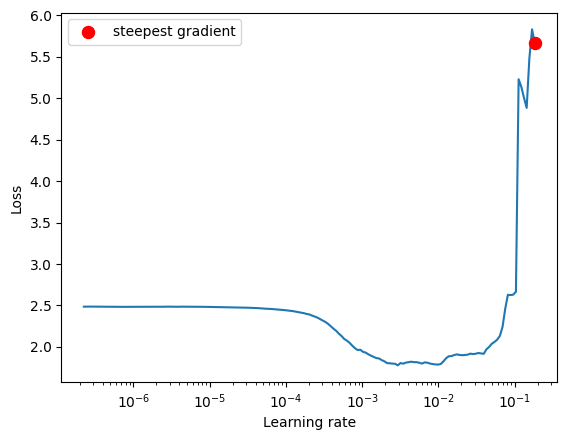

🔍 Class Weights Tensor:
tensor([2.4843, 2.4843, 2.4843, 2.4843, 2.4843, 2.4843, 2.4843, 2.4843, 2.4843,
        2.4843, 2.4843, 2.4843], device='cuda:0')
🔍 Input sample shape: torch.Size([64, 21, 8])
Epoch 1/50 - Train Loss: 1.1090 - Val Loss: 1.0504 - Train Acc: 0.5523 - Val Acc: 0.5621
Epoch 2/50 - Train Loss: 0.6997 - Val Loss: 0.8915 - Train Acc: 0.7351 - Val Acc: 0.6247
Epoch 3/50 - Train Loss: 0.5653 - Val Loss: 0.8188 - Train Acc: 0.7872 - Val Acc: 0.7114
Epoch 4/50 - Train Loss: 0.4955 - Val Loss: 0.9254 - Train Acc: 0.8162 - Val Acc: 0.6844
Epoch 5/50 - Train Loss: 0.4371 - Val Loss: 0.5731 - Train Acc: 0.8361 - Val Acc: 0.7751
Epoch 6/50 - Train Loss: 0.3811 - Val Loss: 0.7253 - Train Acc: 0.8612 - Val Acc: 0.7705
Epoch 7/50 - Train Loss: 0.3532 - Val Loss: 0.3924 - Train Acc: 0.8703 - Val Acc: 0.8522
Epoch 8/50 - Train Loss: 0.3201 - Val Loss: 0.4277 - Train Acc: 0.8853 - Val Acc: 0.8352
Epoch 9/50 - Train Loss: 0.2913 - Val Loss: 0.4088 - Train Acc: 0.8976 - Val Acc: 0.8382

/tmp/ipykernel_3405108/1640688602.py:76: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path))


🔍 LR Finder


 90%|████████▉ | 179/200 [00:03<00:00, 45.48it/s]


Stopping early, the loss has diverged
Learning rate search finished. See the graph with {finder_name}.plot()
LR suggestion: steepest gradient
Suggested LR: 6.83E-04


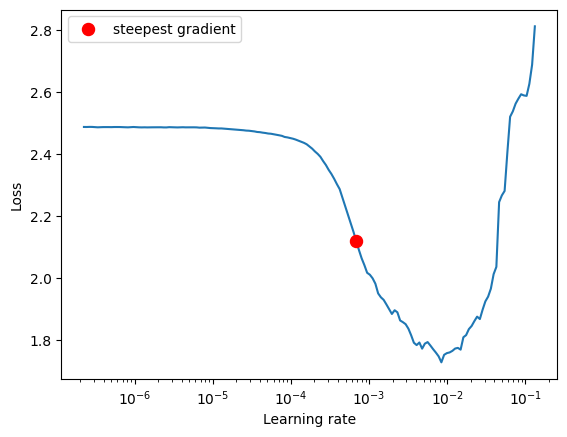

🔍 Class Weights Tensor:
tensor([2.4844, 2.4844, 2.4844, 2.4844, 2.4844, 2.4844, 2.4844, 2.4844, 2.4844,
        2.4844, 2.4844, 2.4844], device='cuda:0')
🔍 Input sample shape: torch.Size([64, 16, 8])
Epoch 1/50 - Train Loss: 0.8982 - Val Loss: 0.9374 - Train Acc: 0.6798 - Val Acc: 0.6469
Epoch 2/50 - Train Loss: 0.5110 - Val Loss: 0.6336 - Train Acc: 0.8176 - Val Acc: 0.7509
Epoch 3/50 - Train Loss: 0.3900 - Val Loss: 0.4981 - Train Acc: 0.8654 - Val Acc: 0.8235
Epoch 4/50 - Train Loss: 0.3256 - Val Loss: 0.3745 - Train Acc: 0.8856 - Val Acc: 0.8652
Epoch 5/50 - Train Loss: 0.2846 - Val Loss: 0.4711 - Train Acc: 0.9029 - Val Acc: 0.8447
Epoch 6/50 - Train Loss: 0.2459 - Val Loss: 0.3095 - Train Acc: 0.9156 - Val Acc: 0.8926
Epoch 7/50 - Train Loss: 0.2147 - Val Loss: 0.4168 - Train Acc: 0.9270 - Val Acc: 0.8709
Epoch 8/50 - Train Loss: 0.2020 - Val Loss: 0.2919 - Train Acc: 0.9326 - Val Acc: 0.8960
Epoch 9/50 - Train Loss: 0.1811 - Val Loss: 0.2672 - Train Acc: 0.9387 - Val Acc: 0.9100

/tmp/ipykernel_3405108/1640688602.py:76: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path))


🔍 LR Finder


 90%|█████████ | 181/200 [00:02<00:00, 89.13it/s] 


Stopping early, the loss has diverged
Learning rate search finished. See the graph with {finder_name}.plot()
LR suggestion: steepest gradient
Suggested LR: 1.55E-01


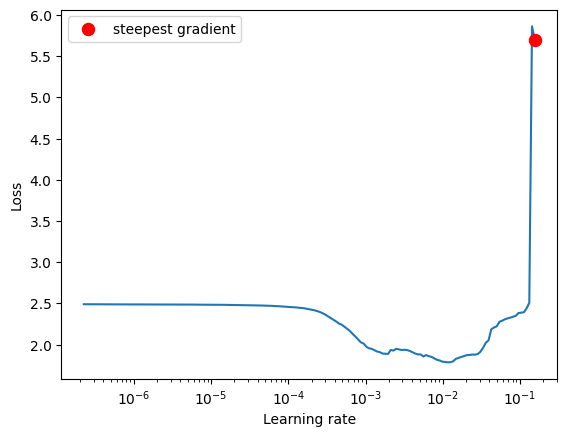

🔍 Class Weights Tensor:
tensor([2.4847, 2.4847, 2.4847, 2.4847, 2.4847, 2.4847, 2.4847, 2.4847, 2.4847,
        2.4847, 2.4847, 2.4847], device='cuda:0')
🔍 Input sample shape: torch.Size([64, 11, 8])
Epoch 1/50 - Train Loss: 0.7535 - Val Loss: 0.6664 - Train Acc: 0.7297 - Val Acc: 0.7652
Epoch 2/50 - Train Loss: 0.3931 - Val Loss: 0.5237 - Train Acc: 0.8621 - Val Acc: 0.8296
Epoch 3/50 - Train Loss: 0.2932 - Val Loss: 0.3855 - Train Acc: 0.8979 - Val Acc: 0.8751
Epoch 4/50 - Train Loss: 0.2512 - Val Loss: 0.3448 - Train Acc: 0.9149 - Val Acc: 0.8851
Epoch 5/50 - Train Loss: 0.2071 - Val Loss: 0.3634 - Train Acc: 0.9305 - Val Acc: 0.8868
Epoch 6/50 - Train Loss: 0.1882 - Val Loss: 0.3666 - Train Acc: 0.9376 - Val Acc: 0.8895
Epoch 7/50 - Train Loss: 0.1599 - Val Loss: 0.2748 - Train Acc: 0.9462 - Val Acc: 0.9107
Epoch 8/50 - Train Loss: 0.1546 - Val Loss: 0.2413 - Train Acc: 0.9501 - Val Acc: 0.9224
Epoch 9/50 - Train Loss: 0.1337 - Val Loss: 0.3292 - Train Acc: 0.9545 - Val Acc: 0.9166

/tmp/ipykernel_3405108/1640688602.py:76: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path))


🔍 LR Finder


 94%|█████████▍| 188/200 [00:04<00:00, 44.27it/s]


Stopping early, the loss has diverged
Learning rate search finished. See the graph with {finder_name}.plot()
LR suggestion: steepest gradient
Suggested LR: 7.40E-04


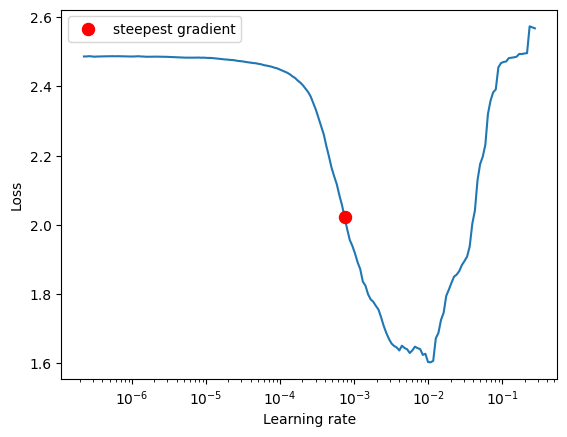

🔍 Class Weights Tensor:
tensor([2.4837, 2.4837, 2.4837, 2.4837, 2.4837, 2.4837, 2.4837, 2.4837, 2.4837,
        2.4837, 2.4837, 2.4837], device='cuda:0')
🔍 Input sample shape: torch.Size([64, 36, 8])
Epoch 1/50 - Train Loss: 1.0637 - Val Loss: 0.9545 - Train Acc: 0.6174 - Val Acc: 0.6453
Epoch 2/50 - Train Loss: 0.5206 - Val Loss: 0.6384 - Train Acc: 0.8115 - Val Acc: 0.7587
Epoch 3/50 - Train Loss: 0.4015 - Val Loss: 0.4183 - Train Acc: 0.8615 - Val Acc: 0.8421
Epoch 4/50 - Train Loss: 0.3197 - Val Loss: 0.4409 - Train Acc: 0.8897 - Val Acc: 0.8072
Epoch 5/50 - Train Loss: 0.2887 - Val Loss: 0.4963 - Train Acc: 0.9082 - Val Acc: 0.8120
Epoch 6/50 - Train Loss: 0.2139 - Val Loss: 0.4167 - Train Acc: 0.9264 - Val Acc: 0.8857
Epoch 7/50 - Train Loss: 0.1928 - Val Loss: 0.4134 - Train Acc: 0.9352 - Val Acc: 0.8721
Epoch 8/50 - Train Loss: 0.1894 - Val Loss: 0.2923 - Train Acc: 0.9388 - Val Acc: 0.8983
Epoch 9/50 - Train Loss: 0.1483 - Val Loss: 0.2252 - Train Acc: 0.9508 - Val Acc: 0.9264

/tmp/ipykernel_3405108/1640688602.py:76: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path))


🔍 LR Finder


 94%|█████████▍| 188/200 [00:04<00:00, 45.04it/s]


Stopping early, the loss has diverged
Learning rate search finished. See the graph with {finder_name}.plot()
LR suggestion: steepest gradient
Suggested LR: 6.83E-04


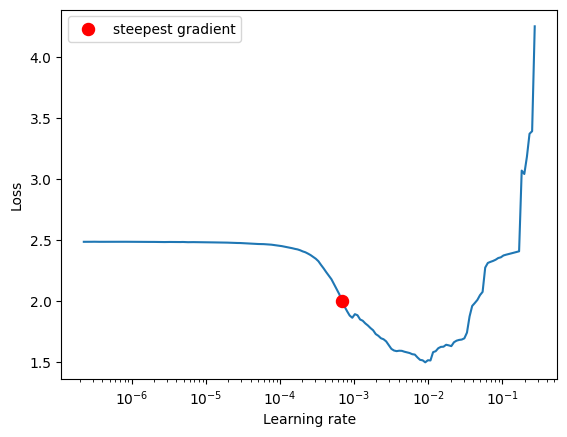

🔍 Class Weights Tensor:
tensor([2.4840, 2.4840, 2.4840, 2.4840, 2.4840, 2.4840, 2.4840, 2.4840, 2.4840,
        2.4840, 2.4840, 2.4840], device='cuda:0')
🔍 Input sample shape: torch.Size([64, 31, 8])
Epoch 1/50 - Train Loss: 0.8934 - Val Loss: 0.7271 - Train Acc: 0.6796 - Val Acc: 0.7246
Epoch 2/50 - Train Loss: 0.4476 - Val Loss: 0.5598 - Train Acc: 0.8402 - Val Acc: 0.7860
Epoch 3/50 - Train Loss: 0.3331 - Val Loss: 0.3834 - Train Acc: 0.8844 - Val Acc: 0.8510
Epoch 4/50 - Train Loss: 0.2762 - Val Loss: 0.5378 - Train Acc: 0.9041 - Val Acc: 0.8028
Epoch 5/50 - Train Loss: 0.2308 - Val Loss: 0.3232 - Train Acc: 0.9214 - Val Acc: 0.8941
Epoch 6/50 - Train Loss: 0.1881 - Val Loss: 0.2513 - Train Acc: 0.9372 - Val Acc: 0.9145
Epoch 7/50 - Train Loss: 0.1772 - Val Loss: 0.2567 - Train Acc: 0.9399 - Val Acc: 0.9094
Epoch 8/50 - Train Loss: 0.1405 - Val Loss: 0.2277 - Train Acc: 0.9526 - Val Acc: 0.9182
Epoch 9/50 - Train Loss: 0.1328 - Val Loss: 0.2878 - Train Acc: 0.9570 - Val Acc: 0.9145

/tmp/ipykernel_3405108/1640688602.py:76: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path))


🔍 LR Finder


 88%|████████▊ | 177/200 [00:03<00:00, 44.86it/s]


Stopping early, the loss has diverged
Learning rate search finished. See the graph with {finder_name}.plot()
LR suggestion: steepest gradient
Suggested LR: 1.12E-01


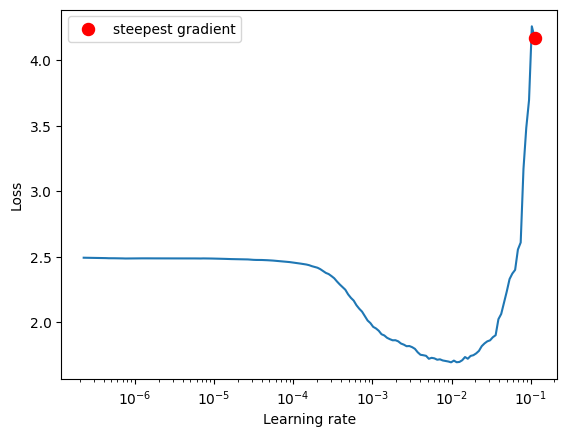

🔍 Class Weights Tensor:
tensor([2.4841, 2.4841, 2.4841, 2.4841, 2.4841, 2.4841, 2.4841, 2.4841, 2.4841,
        2.4841, 2.4841, 2.4841], device='cuda:0')
🔍 Input sample shape: torch.Size([64, 26, 8])
Epoch 1/50 - Train Loss: 0.9127 - Val Loss: 0.7698 - Train Acc: 0.6721 - Val Acc: 0.6744
Epoch 2/50 - Train Loss: 0.4774 - Val Loss: 0.5674 - Train Acc: 0.8284 - Val Acc: 0.7823
Epoch 3/50 - Train Loss: 0.3737 - Val Loss: 0.7208 - Train Acc: 0.8680 - Val Acc: 0.7438
Epoch 4/50 - Train Loss: 0.2903 - Val Loss: 0.3941 - Train Acc: 0.8967 - Val Acc: 0.8530
Epoch 5/50 - Train Loss: 0.2607 - Val Loss: 0.3444 - Train Acc: 0.9111 - Val Acc: 0.8763
Epoch 6/50 - Train Loss: 0.2067 - Val Loss: 0.3873 - Train Acc: 0.9313 - Val Acc: 0.8713
Epoch 7/50 - Train Loss: 0.1884 - Val Loss: 0.3119 - Train Acc: 0.9338 - Val Acc: 0.9129
Epoch 8/50 - Train Loss: 0.1741 - Val Loss: 0.2875 - Train Acc: 0.9427 - Val Acc: 0.9028
Epoch 9/50 - Train Loss: 0.1497 - Val Loss: 0.2813 - Train Acc: 0.9507 - Val Acc: 0.9192

/tmp/ipykernel_3405108/1640688602.py:76: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path))


🔍 LR Finder


 90%|█████████ | 180/200 [00:04<00:00, 43.73it/s]


Stopping early, the loss has diverged
Learning rate search finished. See the graph with {finder_name}.plot()
LR suggestion: steepest gradient
Suggested LR: 1.22E-01


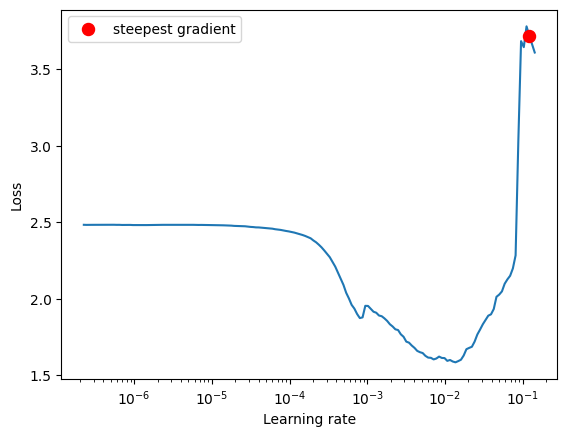

🔍 Class Weights Tensor:
tensor([2.4832, 2.4832, 2.4832, 2.4832, 2.4832, 2.4832, 2.4832, 2.4832, 2.4832,
        2.4832, 2.4832, 2.4832], device='cuda:0')
🔍 Input sample shape: torch.Size([64, 51, 8])
Epoch 1/50 - Train Loss: 0.9922 - Val Loss: 0.8245 - Train Acc: 0.6459 - Val Acc: 0.6376
Epoch 2/50 - Train Loss: 0.4900 - Val Loss: 0.7318 - Train Acc: 0.8218 - Val Acc: 0.7074
Epoch 3/50 - Train Loss: 0.3746 - Val Loss: 0.3777 - Train Acc: 0.8648 - Val Acc: 0.8588
Epoch 4/50 - Train Loss: 0.2733 - Val Loss: 0.2558 - Train Acc: 0.9066 - Val Acc: 0.9083
Epoch 5/50 - Train Loss: 0.2254 - Val Loss: 0.2665 - Train Acc: 0.9228 - Val Acc: 0.8996
Epoch 6/50 - Train Loss: 0.1927 - Val Loss: 0.3301 - Train Acc: 0.9367 - Val Acc: 0.8865
Epoch 7/50 - Train Loss: 0.1519 - Val Loss: 0.3095 - Train Acc: 0.9520 - Val Acc: 0.9112
Epoch 8/50 - Train Loss: 0.1504 - Val Loss: 0.2085 - Train Acc: 0.9524 - Val Acc: 0.9345
Epoch 9/50 - Train Loss: 0.1443 - Val Loss: 0.1891 - Train Acc: 0.9555 - Val Acc: 0.9476

/tmp/ipykernel_3405108/1640688602.py:76: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path))


🔍 LR Finder


 93%|█████████▎| 186/200 [00:04<00:00, 44.06it/s]


Stopping early, the loss has diverged
Learning rate search finished. See the graph with {finder_name}.plot()
LR suggestion: steepest gradient
Suggested LR: 6.83E-04


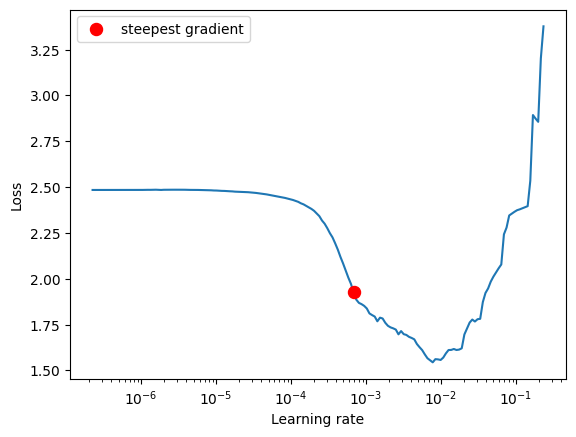

🔍 Class Weights Tensor:
tensor([2.4834, 2.4834, 2.4834, 2.4834, 2.4834, 2.4834, 2.4834, 2.4834, 2.4834,
        2.4834, 2.4834, 2.4834], device='cuda:0')
🔍 Input sample shape: torch.Size([64, 46, 8])
Epoch 1/50 - Train Loss: 0.8980 - Val Loss: 0.6758 - Train Acc: 0.6754 - Val Acc: 0.7025
Epoch 2/50 - Train Loss: 0.4256 - Val Loss: 0.5283 - Train Acc: 0.8440 - Val Acc: 0.7962
Epoch 3/50 - Train Loss: 0.3309 - Val Loss: 0.3187 - Train Acc: 0.8810 - Val Acc: 0.8608
Epoch 4/50 - Train Loss: 0.2544 - Val Loss: 0.2821 - Train Acc: 0.9130 - Val Acc: 0.8949
Epoch 5/50 - Train Loss: 0.2475 - Val Loss: 0.2773 - Train Acc: 0.9168 - Val Acc: 0.9089
Epoch 6/50 - Train Loss: 0.1565 - Val Loss: 0.2229 - Train Acc: 0.9479 - Val Acc: 0.9291
Epoch 7/50 - Train Loss: 0.1524 - Val Loss: 0.2891 - Train Acc: 0.9484 - Val Acc: 0.9139
Epoch 8/50 - Train Loss: 0.1560 - Val Loss: 0.2359 - Train Acc: 0.9503 - Val Acc: 0.9278
Epoch 9/50 - Train Loss: 0.1284 - Val Loss: 0.1673 - Train Acc: 0.9566 - Val Acc: 0.9506

/tmp/ipykernel_3405108/1640688602.py:76: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path))


🔍 LR Finder


 88%|████████▊ | 175/200 [00:03<00:00, 44.12it/s]


Stopping early, the loss has diverged
Learning rate search finished. See the graph with {finder_name}.plot()
LR suggestion: steepest gradient
Suggested LR: 5.35E-04


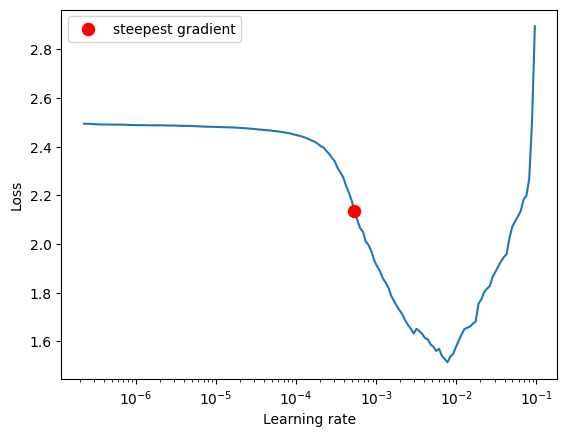

🔍 Class Weights Tensor:
tensor([2.4835, 2.4835, 2.4835, 2.4835, 2.4835, 2.4835, 2.4835, 2.4835, 2.4835,
        2.4835, 2.4835, 2.4835], device='cuda:0')
🔍 Input sample shape: torch.Size([64, 41, 8])
Epoch 1/50 - Train Loss: 1.0354 - Val Loss: 1.0611 - Train Acc: 0.6070 - Val Acc: 0.6171
Epoch 2/50 - Train Loss: 0.5358 - Val Loss: 0.5620 - Train Acc: 0.8010 - Val Acc: 0.7494
Epoch 3/50 - Train Loss: 0.3637 - Val Loss: 0.4896 - Train Acc: 0.8659 - Val Acc: 0.8384
Epoch 4/50 - Train Loss: 0.2628 - Val Loss: 0.3789 - Train Acc: 0.9074 - Val Acc: 0.8747
Epoch 5/50 - Train Loss: 0.2429 - Val Loss: 0.2970 - Train Acc: 0.9162 - Val Acc: 0.8993
Epoch 6/50 - Train Loss: 0.2271 - Val Loss: 0.3231 - Train Acc: 0.9221 - Val Acc: 0.9028
Epoch 7/50 - Train Loss: 0.1542 - Val Loss: 0.3398 - Train Acc: 0.9483 - Val Acc: 0.9169
Epoch 8/50 - Train Loss: 0.1427 - Val Loss: 0.2863 - Train Acc: 0.9520 - Val Acc: 0.9052
Epoch 9/50 - Train Loss: 0.1287 - Val Loss: 0.2173 - Train Acc: 0.9571 - Val Acc: 0.9426

/tmp/ipykernel_3405108/1640688602.py:76: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path))


In [31]:
import os
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from torch.utils.data import DataLoader
from torch_lr_finder import LRFinder

# === Settings ===
base_dir = "/home/HardDisk/Satang/thesis_proj"
save_root = "/home/HardDisk/Satang/thesis_proj/Deep_Learning/cnn/teacher"
os.makedirs(save_root, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
detection_times = [30, 45, 60]
window_sizes = [10, 15, 20]

NUM_EPOCHS = 50
BATCH_SIZE = 64

for T_d in detection_times:
    for T_w in window_sizes:
        print(f"\n🚀 Training SingleStreamCNN2D | Td={T_d}, Tw={T_w}")
        T_len = T_d - T_w + 1
        expected_shape = (T_len, 8)
        folder_name = f"X_csv_split_{T_len}"
        input_dir = os.path.join(base_dir, f"New_{T_d}", f"{T_w}", "split_tws", folder_name)
        train_path = os.path.join(input_dir, "train")
        val_path   = os.path.join(input_dir, "val")
        model_path = os.path.join(save_root, f"cnn2d_Td{T_d}_Tw{T_w}.pth")

        # Load data
        X_train_raw, y_train_raw = load_split_from_folder(train_path, expected_shape)
        X_val_raw, y_val_raw     = load_split_from_folder(val_path, expected_shape)

        # Encode labels
        label_encoder = LabelEncoder()
        y_train_encoded = label_encoder.fit_transform(y_train_raw)

        # SMOTE
        X_train_flat = X_train_raw.reshape(X_train_raw.shape[0], -1)
        X_resampled, y_resampled = SMOTE().fit_resample(X_train_flat, y_train_encoded)
        X_train_bal = X_resampled.reshape(-1, T_len, 8)
        y_train_str = label_encoder.inverse_transform(y_resampled)

        # Dataset — shape: [B, T, 8]
        train_dataset = SingleStream2DDataset(X_train_bal, y_train_str, label_encoder, augment=True)
        val_dataset   = SingleStream2DDataset(X_val_raw, y_val_raw, label_encoder, augment=False)
        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
        val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

        # Class weights
        class_weights_tensor = compute_class_weights(label_encoder.transform(y_train_str), device)

        # LR Finder
        print("🔍 LR Finder")
        model_for_lr = SingleStreamCNN2D(num_classes=len(label_encoder.classes_)).to(device)
        optimizer = torch.optim.AdamW(model_for_lr.parameters(), lr=1e-7, weight_decay=1e-4)
        criterion = torch.nn.CrossEntropyLoss(weight=class_weights_tensor)
        lr_finder = LRFinder(model_for_lr, optimizer, criterion, device=device)
        lr_finder.range_test(train_loader, end_lr=1, num_iter=200)
        lr_finder.plot()
        lr_finder.reset()

        # BEST_LR = pick manually
        BEST_LR = 0.001

        model = SingleStreamCNN2D(num_classes=len(label_encoder.classes_)).to(device)
        optimizer = torch.optim.AdamW(model.parameters(), lr=BEST_LR, weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

        # Train
        train_accs, val_accs, train_losses, val_losses = train_model(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            device=device,
            epochs=NUM_EPOCHS,
            class_weights=class_weights_tensor,
            lr=BEST_LR,
            optimizer=optimizer,
            scheduler=scheduler,
            best_model_path=model_path
        )

        print(f"✅ Saved to {model_path}")

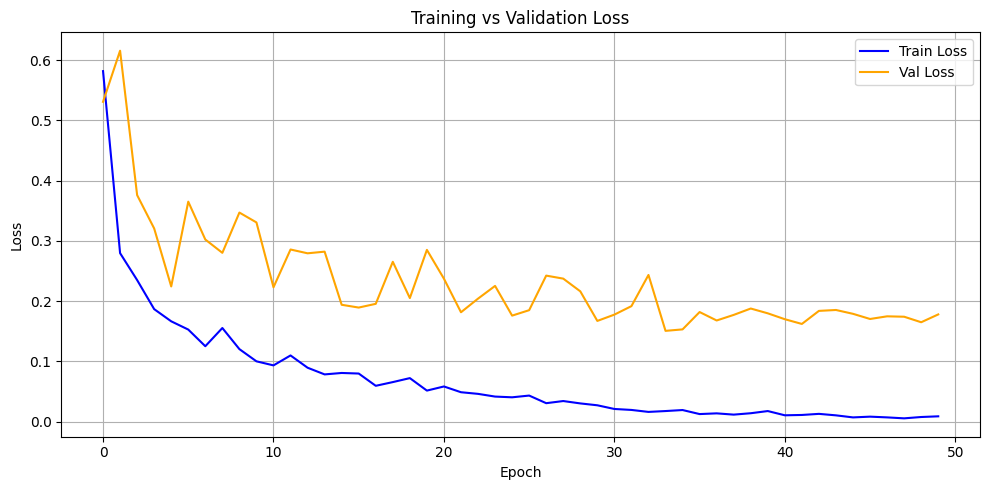

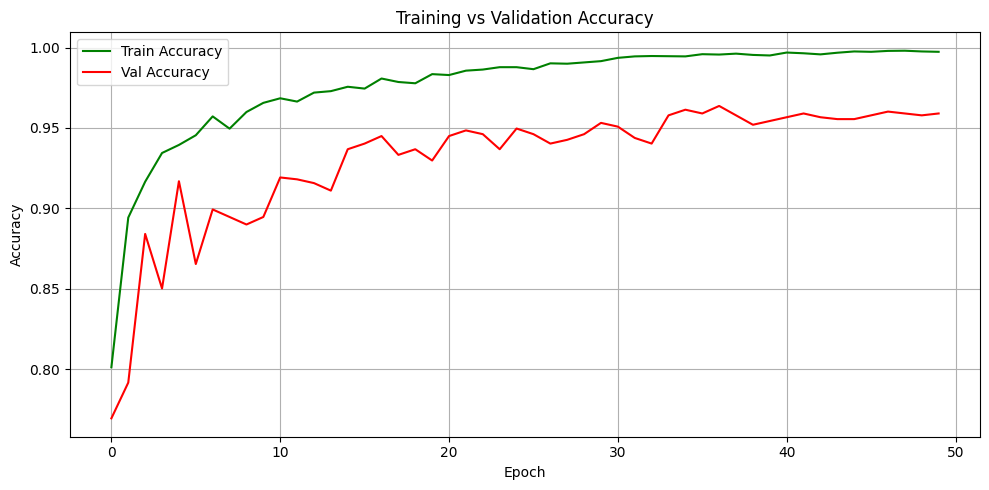

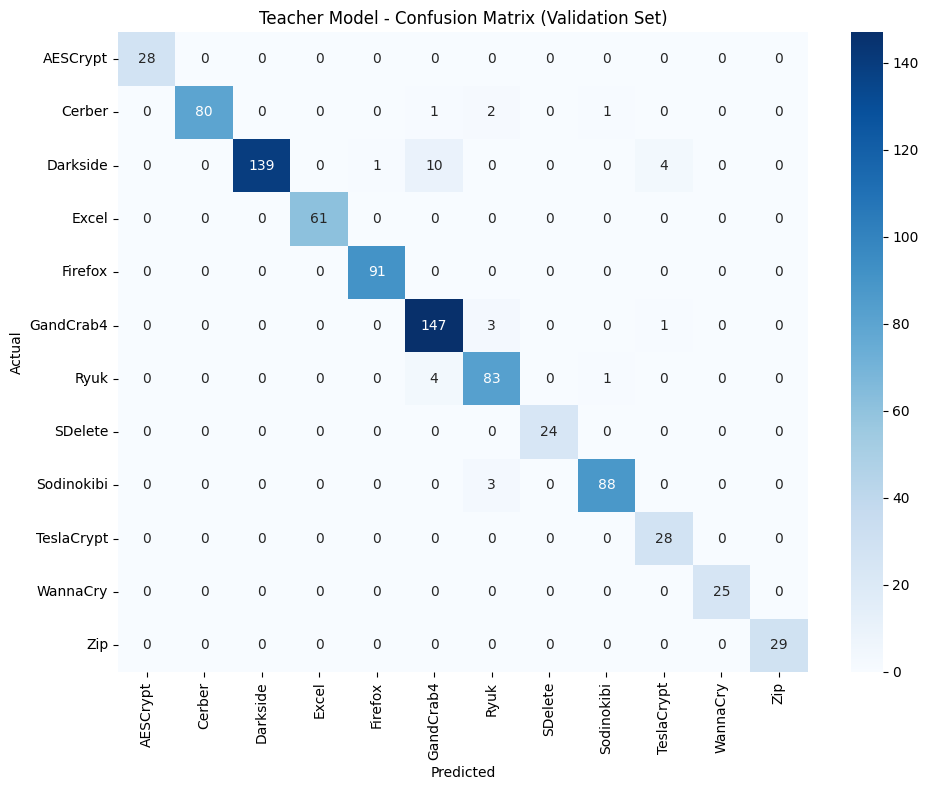


Final Classification Report (Teacher):

              precision    recall  f1-score   support

    AESCrypt       1.00      1.00      1.00        28
      Cerber       1.00      0.95      0.98        84
    Darkside       1.00      0.90      0.95       154
       Excel       1.00      1.00      1.00        61
     Firefox       0.99      1.00      0.99        91
   GandCrab4       0.91      0.97      0.94       151
        Ryuk       0.91      0.94      0.93        88
     SDelete       1.00      1.00      1.00        24
  Sodinokibi       0.98      0.97      0.97        91
  TeslaCrypt       0.85      1.00      0.92        28
    WannaCry       1.00      1.00      1.00        25
         Zip       1.00      1.00      1.00        29

    accuracy                           0.96       854
   macro avg       0.97      0.98      0.97       854
weighted avg       0.97      0.96      0.96       854


Final Training Accuracy: 0.9974
Final Validation Accuracy: 0.9590


In [34]:
# === 🔍 Plot training curves
plot_loss_curve(train_losses, val_losses)
plot_accuracy_curve(train_accs, val_accs)

# === 📊 Evaluate on validation set (same used during training)
final_teacher.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for streams, labels in val_loader:
        streams = [s.to(device) for s in streams]
        labels = labels.to(device)
        outputs = final_teacher(streams)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# === Confusion Matrix & Report
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Teacher Model - Confusion Matrix (Validation Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print("\nFinal Classification Report (Teacher):\n")
print(classification_report(all_labels, all_preds, target_names=label_encoder.classes_))

print(f"\nFinal Training Accuracy: {train_accs[-1]:.4f}")
print(f"Final Validation Accuracy: {val_accs[-1]:.4f}")

🧠 Multi-class AUC (macro): 0.9992


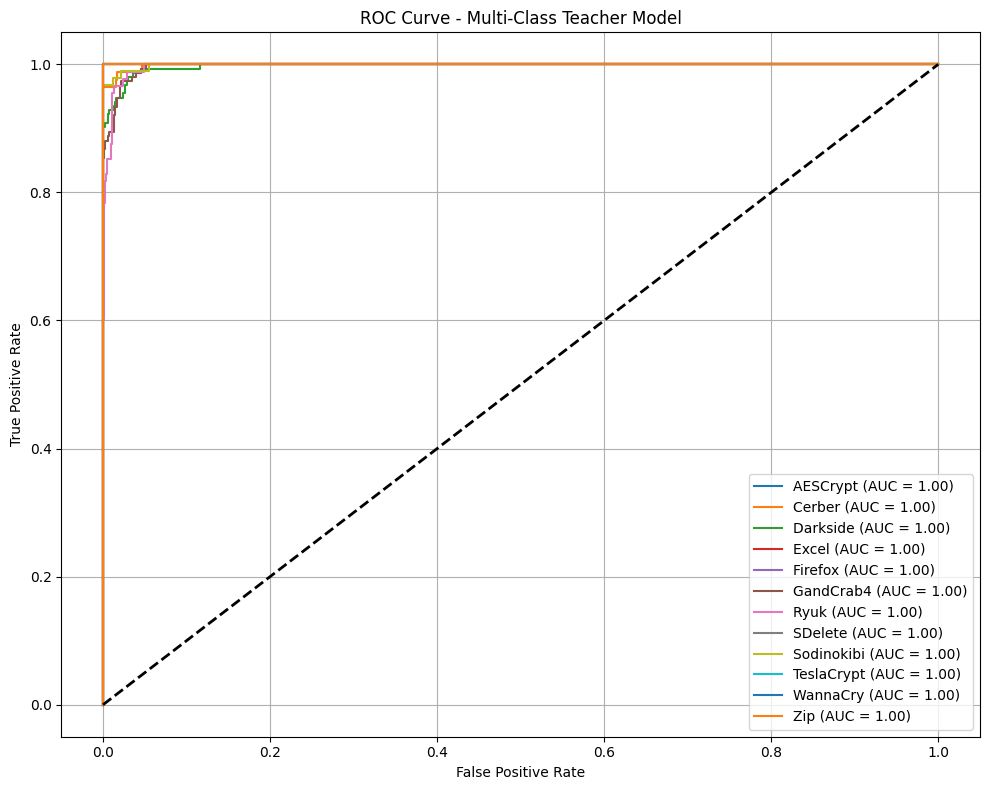

In [35]:
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# === 1. Get predictions on validation set ===
final_teacher.eval()
y_true = []
y_probs = []

with torch.no_grad():
    for streams, labels in val_loader:
        streams = [s.to(device) for s in streams]
        labels = labels.cpu().numpy()
        outputs = final_teacher(streams)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        
        y_probs.extend(probs)
        y_true.extend(labels)

y_true = np.array(y_true)
y_probs = np.array(y_probs)

# === 2. Binarize labels for ROC AUC ===
y_true_bin = label_binarize(y_true, classes=range(len(label_encoder.classes_)))

# === 3. Compute AUC score (macro-average) ===
auc_macro = roc_auc_score(y_true_bin, y_probs, average="macro", multi_class="ovr")
print(f"🧠 Multi-class AUC (macro): {auc_macro:.4f}")

# === 4. Plot ROC curves per class ===
plt.figure(figsize=(10, 8))
for i in range(len(label_encoder.classes_)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{label_encoder.classes_[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--", lw=2)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Multi-Class Teacher Model")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


In [36]:
import torch
import torch.nn as nn
import time
import os
import psutil
import copy
from thop import profile

# === Profiling functions using clean model copies ===
def get_stream_macs_params(stream, CHUNK_SIZE):
    dummy_input = torch.randn(1, 1, CHUNK_SIZE)
    stream_copy = copy.deepcopy(stream)
    macs, params = profile(stream_copy, inputs=(dummy_input,), verbose=False)
    return macs, params

def get_linear_macs_params(layer, in_features):
    dummy_input = torch.randn(1, in_features)
    layer_copy = copy.deepcopy(layer)
    macs, params = profile(layer_copy, inputs=(dummy_input,), verbose=False)
    return macs, params

# === Utility functions ===
def get_model_size(model):
    temp_path = "temp_model.pth"
    torch.save(model.state_dict(), temp_path)
    size_mb = os.path.getsize(temp_path) / (1024 ** 2)
    os.remove(temp_path)
    return size_mb

def measure_latency(model, inputs, n_runs=100):
    model.eval()
    with torch.no_grad():
        start = time.time()
        for _ in range(n_runs):
            model(inputs)
        end = time.time()
    return (end - start) / n_runs * 1000

def measure_cpu_usage(model, inputs, duration=2):
    model.eval()
    process = psutil.Process(os.getpid())
    num_cpus = psutil.cpu_count(logical=True)
    _ = process.cpu_percent(interval=None)
    with torch.no_grad():
        start_time = time.time()
        while time.time() - start_time < duration:
            model(inputs)
    total_cpu_percent = process.cpu_percent(interval=None)
    return total_cpu_percent / num_cpus

# === Final evaluation logic ===
def evaluate_full_model(model_class, model_path, input_length, *args, **kwargs):
    # 🔁 Load profiling and clean model instances
    prof_model = model_class(input_length=input_length, *args, **kwargs)
    prof_model.load_state_dict(torch.load(model_path))
    prof_model.eval()

    clean_model = model_class(input_length=input_length, *args, **kwargs)
    clean_model.load_state_dict(torch.load(model_path))
    clean_model.eval()

    total_macs, total_params = 0, 0

    print("🔍 Stream MAC breakdown:")
    for i in range(8):
        macs_i, params_i = get_stream_macs_params(prof_model.streams[i], input_length)
        print(f"  Stream[{i}] MACs: {macs_i}, Params: {params_i}")
        total_macs += macs_i
        total_params += params_i

    # FC block
    print("\n🔍 FC Layer breakdown:")
    fc0, fc3, fc6, fc8, fc9 = prof_model.fc[1], prof_model.fc[4], prof_model.fc[7], prof_model.fc[8], prof_model.fc[9]
    macs_fc0, params_fc0 = get_linear_macs_params(fc0, in_features=2048)
    macs_fc3, params_fc3 = get_linear_macs_params(fc3, in_features=512)
    macs_fc6, params_fc6 = get_linear_macs_params(fc6, in_features=256)
    macs_fc8, params_fc8 = get_linear_macs_params(fc8, in_features=128)
    total_macs += macs_fc0 + macs_fc3 + macs_fc6 + macs_fc8
    total_params += params_fc0 + params_fc3 + params_fc6 + params_fc8
    print(f"  FC[0] (2048→512):  {macs_fc0}, Params: {params_fc0}")
    print(f"  FC[3] (512→256):  {macs_fc3}, Params: {params_fc3}")
    print(f"  FC[6] (256→128):  {macs_fc6}, Params: {params_fc6}")
    print(f"  FC[8] (128→classes): {macs_fc8}, Params: {params_fc8}")

    # Projection
    print("\n🔍 Projection Layer:")
    macs_proj, params_proj = get_linear_macs_params(prof_model.proj, in_features=2048)
    total_macs += macs_proj
    total_params += params_proj
    print(f"  Proj (2048→128): {macs_proj}, Params: {params_proj}")

    flops = 2 * total_macs
    size_mb = get_model_size(clean_model)

    dummy_inputs = [torch.randn(1, 1, input_length) for _ in range(8)]
    latency = measure_latency(clean_model, dummy_inputs)
    cpu_usage = measure_cpu_usage(clean_model, dummy_inputs)

    return {
        "Model Size (MB)": round(size_mb, 4),
        "Latency (ms)": round(latency, 3),
        "CPU Usage (%)": round(cpu_usage, 2),
        "Total MACs": int(total_macs),
        "FLOPs": int(flops),
        "Total Params": int(total_params)
    }

# === Usage ===
# You must define your StudentCNN class and load the model first
model = MultiStreamCNN(input_length=CHUNK_SIZE, num_classes=len(label_encoder.classes_))
model.load_state_dict(torch.load("teacher_full.pth"))
# Then:
#torch.save(model.state_dict(), "student_model.pth")
stats = evaluate_full_model(MultiStreamCNN, "teacher_full.pth", input_length=CHUNK_SIZE, num_classes=len(label_encoder.classes_))
for k, v in stats.items():
    print(f"{k}: {v}")


/tmp/ipykernel_2377727/3605911462.py:111: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("teacher_full.pth"))


FileNotFoundError: [Errno 2] No such file or directory: 'teacher_full.pth'

/tmp/ipykernel_3245880/3475220102.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("teacher_full.pth"))


=== 🧪 Final Test Set Classification Report ===
              precision    recall  f1-score   support

    AESCrypt     1.0000    0.9464    0.9725       112
      Cerber     0.9916    0.9673    0.9793       245
    Darkside     0.9822    0.9085    0.9439       426
       Excel     1.0000    1.0000    1.0000       249
     Firefox     0.9736    0.9847    0.9791       262
   GandCrab4     0.8430    0.9577    0.8967       426
        Ryuk     0.9108    0.9142    0.9125       268
     SDelete     0.9487    1.0000    0.9737       111
  Sodinokibi     0.9480    0.8778    0.9115       270
  TeslaCrypt     0.9161    0.8912    0.9034       147
    WannaCry     1.0000    1.0000    1.0000       128
         Zip     1.0000    1.0000    1.0000       113

    accuracy                         0.9467      2757
   macro avg     0.9595    0.9540    0.9561      2757
weighted avg     0.9494    0.9467    0.9471      2757



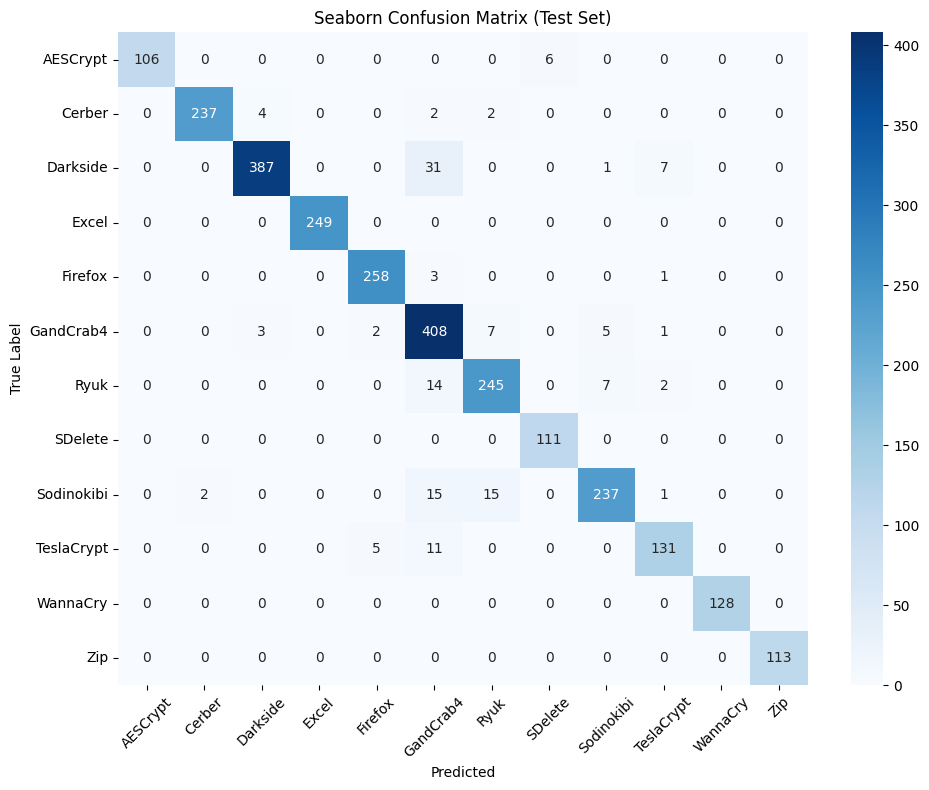

In [ ]:
# expected_shape = (CHUNK_SIZE, NUM_FEATURES)
# X_test, y_test = load_split_from_folder(os.path.join(INPUT_DIR, "test"), expected_shape)
# y_test_str = y_test

# test_dataset = MultiStreamDataset(X_test, y_test_str, label_encoder, augment=False)
# test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

# from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# # Rebuild same model architecture
# model = MultiStreamCNN(input_length=CHUNK_SIZE, num_classes=len(label_encoder.classes_))
# model.load_state_dict(torch.load("teacher_full.pth"))
# model.to(device)
# model.eval()
# all_preds = []
# all_labels = []

# with torch.no_grad():
#     for streams, labels in test_loader:
#         # Move to device
#         streams = [s.to(device) for s in streams]
#         labels = labels.to(device)

#         outputs = model(streams)
#         preds = outputs.argmax(dim=1)

#         all_preds.extend(preds.cpu().numpy())
#         all_labels.extend(labels.cpu().numpy())

# # Inverse-transform for reporting
# pred_labels_str = label_encoder.inverse_transform(all_preds)
# true_labels_str = label_encoder.inverse_transform(all_labels)

# # === 5. Classification Report
# print("=== 🧪 Final Test Set Classification Report ===")
# print(classification_report(true_labels_str, pred_labels_str, digits=4))

# # === 6. Seaborn Confusion Matrix
# cm = confusion_matrix(true_labels_str, pred_labels_str, labels=label_encoder.classes_)
# plt.figure(figsize=(10, 8))
# sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
# plt.xlabel("Predicted")
# plt.ylabel("True Label")
# plt.title("Seaborn Confusion Matrix (Test Set)")
# plt.xticks(rotation=45)
# plt.yticks(rotation=0)
# plt.tight_layout()
# plt.show()

In [12]:
import torch
import torch.nn as nn

class StudentCNN(nn.Module):
    def __init__(self, input_length, num_classes=12):
        super().__init__()
        self.streams = nn.ModuleList([
            nn.Sequential(
                nn.Conv1d(1, 4, kernel_size=3, padding=1),  # reduced filters
                nn.ReLU(),
                nn.Conv1d(4, 8, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.AdaptiveAvgPool1d(1),
                nn.Flatten()
            ) for _ in range(8)
        ])

        self.fc = nn.Sequential(
            nn.Linear(8 * 8, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )

        # 🔄 Smaller projection for lightweight feature distillation
        self.proj = nn.Linear(8 * 8, 128)

    def forward(self, streams, return_features=False):
        features = [self.streams[i](streams[i]) for i in range(8)]
        x = torch.cat(features, dim=1)  # Shape: [B, 64]

        if return_features:
            feat_proj = self.proj(x)  # [B, 128]
            return self.fc(x), feat_proj

        return self.fc(x)


In [13]:
import torch.nn.functional as F

def distillation_loss(student_logits, teacher_logits, student_feat, teacher_feat, true_labels, T=3.0, alpha=0.5, beta=0.3, gamma=0.2):

    # Hard loss
    ce_loss = F.cross_entropy(student_logits, true_labels)

    # Soft loss (logits)
    soft_teacher = F.softmax(teacher_logits / T, dim=1)
    soft_student = F.log_softmax(student_logits / T, dim=1)
    kl_loss = F.kl_div(soft_student, soft_teacher, reduction='batchmean') * (T * T)

    # Feature loss (projection-matched MSE)
    feat_loss = F.mse_loss(student_feat, teacher_feat)

    return alpha * ce_loss + beta * kl_loss + gamma * feat_loss


In [14]:
# === DATASET CLASS ===
class MultiStreamDataset(Dataset):
    def __init__(self, data, labels, label_encoder, augment=False):
        self.data = data
        self.labels = label_encoder.transform(labels)
        self.augment = augment

    def __len__(self):
        return len(self.data)

    def augment_stream(self, stream):
        jitter = np.random.normal(0, 0.01, stream.shape)
        scale = np.random.normal(1.0, 0.05, stream.shape)
        return stream * scale + jitter

    def __getitem__(self, idx):
        sample = self.data[idx]
        # if idx == 0:
        #     print("🔍 Raw feature sample:")
        #     print(sample)
        #     print("Min:", sample.min(), "Max:", sample.max())
        streams = [sample[:, i].reshape(1, -1).astype(np.float32) for i in range(sample.shape[1])]
        if self.augment:
            streams = [self.augment_stream(s.copy()) for s in streams]
        streams = [torch.tensor(s).float() for s in streams]
        label = torch.tensor(self.labels[idx])
        return streams, label


In [15]:
import torch
import torch.nn as nn
import torch.optim as optim

def train_distilled_dual(student, teacher, student_train_loader, teacher_train_loader,
                         student_val_loader, teacher_val_loader,
                         device, epochs=50, lr=0.0005, class_weights=None,
                         T=3.0, alpha=0.5, beta=0.3, gamma=0.3,
                         best_model_path="best_student.pth"):

    teacher.eval()
    student.to(device)
    teacher.to(device)

    optimizer = optim.Adam(student.parameters(), lr=lr)
    criterion_ce = nn.CrossEntropyLoss(weight=class_weights)

    best_val_acc = 0
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    for epoch in range(epochs):
        student.train()
        running_loss, correct = 0.0, 0

        for (student_inputs, labels_s), (teacher_inputs, labels_t) in zip(student_train_loader, teacher_train_loader):
            # === Student Inputs: list of 8 feature tensors [B, 1, T]
            if isinstance(student_inputs, (list, tuple)):
                student_inputs = [s.to(device) for s in student_inputs]
            else:
                raise TypeError(f"Expected student_inputs to be list/tuple, got {type(student_inputs)}")

            # === Teacher Inputs: single 2D tensor [B, 1, T_len, 8]
            if isinstance(teacher_inputs, (list, tuple)):
                teacher_inputs = teacher_inputs[0]
            teacher_inputs = teacher_inputs.to(device)

            labels = labels_s.to(device)

            # Debug shape
            # if epoch == 0:
            #     print(f"[DEBUG] student_inputs[0] shape: {student_inputs[0].shape}")
            #     print(f"[DEBUG] teacher_inputs shape: {teacher_inputs.shape}")
            #     print(f"[DEBUG] labels shape: {labels.shape}")

            # === Forward Pass
            student_logits, student_feat = student(student_inputs, return_features=True)
            with torch.no_grad():
                teacher_logits, teacher_feat = teacher(teacher_inputs, return_features=True)

            loss = distillation_loss(
                student_logits, teacher_logits,
                student_feat, teacher_feat,
                labels,
                T=T, alpha=alpha, beta=beta, gamma=gamma
            )

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            correct += (student_logits.argmax(dim=1) == labels).sum().item()

        train_acc = correct / len(student_train_loader.dataset)
        train_loss = running_loss / len(student_train_loader)
        train_losses.append(train_loss)
        train_accuracies.append(train_acc)

        # === Validation
        student.eval()
        val_loss, val_correct = 0.0, 0
        with torch.no_grad():
            for (x_student, labels), (x_teacher, _) in zip(student_val_loader, teacher_val_loader):
                if isinstance(x_student, (list, tuple)):
                    x_student = [s.to(device) for s in x_student]
                else:
                    raise TypeError(f"Expected x_student to be list/tuple, got {type(x_student)}")

                if isinstance(x_teacher, (list, tuple)):
                    x_teacher = x_teacher[0]
                x_teacher = x_teacher.to(device)

                labels = labels.to(device)

                outputs = student(x_student)
                loss = criterion_ce(outputs, labels)
                val_loss += loss.item()
                val_correct += (outputs.argmax(dim=1) == labels).sum().item()

        val_acc = val_correct / len(student_val_loader.dataset)
        val_losses.append(val_loss / len(student_val_loader))
        val_accuracies.append(val_acc)

        print(f"[Distill] Epoch {epoch+1:02d}/{epochs} - "
              f"Train Loss: {train_loss:.4f} - Train Acc: {train_acc:.4f} "
              f"- Val Loss: {val_losses[-1]:.4f} - Val Acc: {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(student.state_dict(), best_model_path)

    student.load_state_dict(torch.load(best_model_path))
    return train_accuracies, val_accuracies, train_losses, val_losses

In [24]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from torch_lr_finder import LRFinder

# This code needs external class definitions like:
# - load_split_from_folder
# - MultiStreamDataset (2D-aware)
# - compute_class_weights
# - train_distilled
# - StudentCNN2D
# - SingleStreamCNN2D

# Ensure these are imported or defined before running this code

# === Config
base_dir = "/home/HardDisk/Satang/thesis_proj"
teacher_dir = "/home/HardDisk/Satang/thesis_proj/Deep_Learning/cnn/teacher"
save_root = "/home/HardDisk/Satang/thesis_proj/Deep_Learning/cnn/student"
os.makedirs(save_root, exist_ok=True)

detection_times = [30, 45, 60]
window_sizes = [10, 15, 20]
NUM_EPOCHS = 50
BATCH_SIZE = 64
NUM_FEATURES = 8
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for T_d in detection_times:
    for T_w in window_sizes:
        print(f"\n🚀 Knowledge Distillation for Td={T_d}, Tw={T_w}")
        T_len = T_d - T_w + 1
        expected_shape = (T_len, NUM_FEATURES)
        folder = f"X_csv_split_{T_len}"
        input_dir = os.path.join(base_dir, f"New_{T_d}", f"{T_w}", "split_tws", folder)
        train_path = os.path.join(input_dir, "train")
        val_path = os.path.join(input_dir, "val")

        # === Load Data
        X_train, y_train = load_split_from_folder(train_path, expected_shape)
        X_val, y_val = load_split_from_folder(val_path, expected_shape)

        # === SMOTE
        label_encoder = LabelEncoder()
        y_train_enc = label_encoder.fit_transform(y_train)
        X_train_flat = X_train.reshape(X_train.shape[0], -1)
        X_bal, y_bal = SMOTE().fit_resample(X_train_flat, y_train_enc)
        X_train_res = X_bal.reshape(-1, T_len, NUM_FEATURES)
        y_train_res = label_encoder.inverse_transform(y_bal)

        # === Dataset
        # Dataset for Student (Multi-Stream)
        student_train_dataset = MultiStreamDataset(X_train_res, y_train_res, label_encoder, augment=True)
        student_val_dataset = MultiStreamDataset(X_val, y_val, label_encoder, augment=False)

        student_train_loader = DataLoader(student_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
        student_val_loader   = DataLoader(student_val_dataset, batch_size=BATCH_SIZE, shuffle=False)

        # Dataset for Teacher (2D Input)
        teacher_train_dataset = SingleStream2DDataset(X_train_res, y_train_res, label_encoder, augment=True)
        teacher_val_dataset   = SingleStream2DDataset(X_val, y_val, label_encoder, augment=False)

        teacher_train_loader = DataLoader(teacher_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
        teacher_val_loader   = DataLoader(teacher_val_dataset, batch_size=BATCH_SIZE, shuffle=False)

        # === Load Teacher (2D CNN)
        teacher_path = os.path.join(teacher_dir, f"cnn2d_Td{T_d}_Tw{T_w}.pth")
        teacher = SingleStreamCNN2D(num_classes=len(label_encoder.classes_)).to(device)
        teacher.load_state_dict(torch.load(teacher_path, map_location=device))
        teacher.eval()

        # === Class Weights
        class_weights = compute_class_weights(label_encoder.transform(y_train_res), device)

        # === LR Finder
        student = StudentCNN(input_length=T_len, num_classes=len(label_encoder.classes_)).to(device)
        # optimizer = torch.optim.Adam(model_for_lr.parameters(), lr=1e-7)
        # criterion = nn.CrossEntropyLoss(weight=class_weights)
        # print("🔍 Finding optimal learning rate...")
        # lr_finder = LRFinder(model_for_lr, optimizer, criterion, device=device)
        # lr_finder.range_test(student_train_loader, end_lr=1, num_iter=200)
        # lr_finder.plot()
        # lr_finder.reset()
        BEST_LR = 0.001  # Manually update this after inspecting plots

        # === Train Student KD
        train_accs, val_accs, train_losses, val_losses = train_distilled_dual(
            student=student,
            teacher=teacher,
            student_train_loader=student_train_loader,
            teacher_train_loader=teacher_train_loader,
            student_val_loader=student_val_loader,
            teacher_val_loader=teacher_val_loader,
            device=device,
            epochs=NUM_EPOCHS,
            lr=BEST_LR,
            class_weights=class_weights,
            T = 3.0,
            alpha = 0.6, # CE
            beta  = 0.1,  # KL
            gamma = 0.3,  # MSE
            best_model_path=os.path.join(save_root, f"student_KD_Td{T_d}_Tw{T_w}.pth")
        )


🚀 Knowledge Distillation for Td=30, Tw=10


/tmp/ipykernel_1375046/3648060693.py:76: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  teacher.load_state_dict(torch.load(teacher_path, map_location=device))


[Distill] Epoch 01/50 - Train Loss: 3.0731 - Train Acc: 0.4920 - Val Loss: 1.1477 - Val Acc: 0.5907
[Distill] Epoch 02/50 - Train Loss: 2.7622 - Train Acc: 0.7031 - Val Loss: 1.0576 - Val Acc: 0.6102
[Distill] Epoch 03/50 - Train Loss: 2.7120 - Train Acc: 0.7364 - Val Loss: 0.9886 - Val Acc: 0.6428
[Distill] Epoch 04/50 - Train Loss: 2.6664 - Train Acc: 0.7644 - Val Loss: 0.9283 - Val Acc: 0.6618
[Distill] Epoch 05/50 - Train Loss: 2.6352 - Train Acc: 0.7825 - Val Loss: 0.8452 - Val Acc: 0.6999
[Distill] Epoch 06/50 - Train Loss: 2.6093 - Train Acc: 0.8041 - Val Loss: 0.8186 - Val Acc: 0.7089
[Distill] Epoch 07/50 - Train Loss: 2.5867 - Train Acc: 0.8200 - Val Loss: 0.7346 - Val Acc: 0.7751
[Distill] Epoch 08/50 - Train Loss: 2.5663 - Train Acc: 0.8345 - Val Loss: 0.7562 - Val Acc: 0.7500
[Distill] Epoch 09/50 - Train Loss: 2.5568 - Train Acc: 0.8460 - Val Loss: 0.6802 - Val Acc: 0.7846
[Distill] Epoch 10/50 - Train Loss: 2.5467 - Train Acc: 0.8549 - Val Loss: 0.6760 - Val Acc: 0.7806


/tmp/ipykernel_1375046/1760657418.py:103: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  student.load_state_dict(torch.load(best_model_path))
/tmp/ipykernel_1375046/364806069

[Distill] Epoch 01/50 - Train Loss: 3.0705 - Train Acc: 0.5814 - Val Loss: 1.1135 - Val Acc: 0.6109
[Distill] Epoch 02/50 - Train Loss: 2.7997 - Train Acc: 0.7563 - Val Loss: 0.9538 - Val Acc: 0.6951
[Distill] Epoch 03/50 - Train Loss: 2.7248 - Train Acc: 0.8075 - Val Loss: 0.8659 - Val Acc: 0.7153
[Distill] Epoch 04/50 - Train Loss: 2.6981 - Train Acc: 0.8294 - Val Loss: 0.8333 - Val Acc: 0.7373
[Distill] Epoch 05/50 - Train Loss: 2.6651 - Train Acc: 0.8491 - Val Loss: 0.7232 - Val Acc: 0.7715
[Distill] Epoch 06/50 - Train Loss: 2.6523 - Train Acc: 0.8585 - Val Loss: 0.6958 - Val Acc: 0.7874
[Distill] Epoch 07/50 - Train Loss: 2.6333 - Train Acc: 0.8664 - Val Loss: 0.6799 - Val Acc: 0.7984
[Distill] Epoch 08/50 - Train Loss: 2.6245 - Train Acc: 0.8742 - Val Loss: 0.6518 - Val Acc: 0.8140
[Distill] Epoch 09/50 - Train Loss: 2.6234 - Train Acc: 0.8784 - Val Loss: 0.6651 - Val Acc: 0.8022
[Distill] Epoch 10/50 - Train Loss: 2.6067 - Train Acc: 0.8846 - Val Loss: 0.6473 - Val Acc: 0.8079


...

/tmp/ipykernel_1375046/1760657418.py:103: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  student.load_state_dict(torch.load(best_model_path))
/tmp/ipykernel_1375046/364806069

[Distill] Epoch 01/50 - Train Loss: 3.3005 - Train Acc: 0.4226 - Val Loss: 1.2916 - Val Acc: 0.5823
[Distill] Epoch 02/50 - Train Loss: 2.8341 - Train Acc: 0.7393 - Val Loss: 1.0007 - Val Acc: 0.6532
[Distill] Epoch 03/50 - Train Loss: 2.7411 - Train Acc: 0.7962 - Val Loss: 0.9888 - Val Acc: 0.6684
[Distill] Epoch 04/50 - Train Loss: 2.6911 - Train Acc: 0.8272 - Val Loss: 0.8295 - Val Acc: 0.7089
[Distill] Epoch 05/50 - Train Loss: 2.6615 - Train Acc: 0.8506 - Val Loss: 0.7818 - Val Acc: 0.7405
[Distill] Epoch 06/50 - Train Loss: 2.6461 - Train Acc: 0.8706 - Val Loss: 0.7416 - Val Acc: 0.7418
[Distill] Epoch 07/50 - Train Loss: 2.6173 - Train Acc: 0.8830 - Val Loss: 0.6993 - Val Acc: 0.7658
[Distill] Epoch 08/50 - Train Loss: 2.6145 - Train Acc: 0.8850 - Val Loss: 0.6505 - Val Acc: 0.7987
[Distill] Epoch 09/50 - Train Loss: 2.6057 - Train Acc: 0.8936 - Val Loss: 0.6625 - Val Acc: 0.7937
[Distill] Epoch 10/50 - Train Loss: 2.5919 - Train Acc: 0.9014 - Val Loss: 0.6430 - Val Acc: 0.8266


/tmp/ipykernel_1375046/1760657418.py:103: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  student.load_state_dict(torch.load(best_model_path))
/tmp/ipykernel_1375046/364806069

[Distill] Epoch 01/50 - Train Loss: 3.2269 - Train Acc: 0.4417 - Val Loss: 1.3971 - Val Acc: 0.5269
[Distill] Epoch 02/50 - Train Loss: 2.7973 - Train Acc: 0.7188 - Val Loss: 1.0256 - Val Acc: 0.6218
[Distill] Epoch 03/50 - Train Loss: 2.7166 - Train Acc: 0.7651 - Val Loss: 0.9203 - Val Acc: 0.6475
[Distill] Epoch 04/50 - Train Loss: 2.6637 - Train Acc: 0.8067 - Val Loss: 0.8661 - Val Acc: 0.6920
[Distill] Epoch 05/50 - Train Loss: 2.6287 - Train Acc: 0.8305 - Val Loss: 0.7976 - Val Acc: 0.7119
[Distill] Epoch 06/50 - Train Loss: 2.6108 - Train Acc: 0.8520 - Val Loss: 0.8014 - Val Acc: 0.7482
[Distill] Epoch 07/50 - Train Loss: 2.5722 - Train Acc: 0.8695 - Val Loss: 0.6975 - Val Acc: 0.7693
[Distill] Epoch 08/50 - Train Loss: 2.5812 - Train Acc: 0.8769 - Val Loss: 0.6981 - Val Acc: 0.7869
[Distill] Epoch 09/50 - Train Loss: 2.5551 - Train Acc: 0.8873 - Val Loss: 0.6813 - Val Acc: 0.7752
[Distill] Epoch 10/50 - Train Loss: 2.5483 - Train Acc: 0.8961 - Val Loss: 0.6531 - Val Acc: 0.7869


/tmp/ipykernel_1375046/1760657418.py:103: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  student.load_state_dict(torch.load(best_model_path))


In [40]:
import torch
import torch.nn as nn
import torch.optim as optim

def train_student_baseline(student, train_loader, val_loader, device,
                           epochs=50, lr=0.0005, class_weights=None,
                           best_model_path="best_student_baseline.pth"):
    
    student.to(device)
    optimizer = optim.Adam(student.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    best_val_acc = 0
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    for epoch in range(epochs):
        student.train()
        total_loss, correct = 0.0, 0

        for streams, labels in train_loader:
            streams = [s.to(device) for s in streams]
            labels = labels.to(device)

            outputs = student(streams)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            correct += (outputs.argmax(dim=1) == labels).sum().item()

        train_acc = correct / len(train_loader.dataset)
        train_losses.append(total_loss / len(train_loader))
        train_accuracies.append(train_acc)

        # === Validation ===
        student.eval()
        val_loss, val_correct = 0.0, 0
        with torch.no_grad():
            for streams, labels in val_loader:
                streams = [s.to(device) for s in streams]
                labels = labels.to(device)

                outputs = student(streams)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                val_correct += (outputs.argmax(dim=1) == labels).sum().item()

        val_acc = val_correct / len(val_loader.dataset)
        val_losses.append(val_loss / len(val_loader))
        val_accuracies.append(val_acc)

        print(f"[Baseline] Epoch {epoch+1:02d}/{epochs} - "
              f"Train Loss: {train_losses[-1]:.4f} - Train Acc: {train_acc:.4f} "
              f"- Val Loss: {val_losses[-1]:.4f} - Val Acc: {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(student.state_dict(), best_model_path)

    student.load_state_dict(torch.load(best_model_path))
    return train_accuracies, val_accuracies, train_losses, val_losses


In [43]:
import os
import torch
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from torch.utils.data import DataLoader
base_dir = "/home/HardDisk/Satang/thesis_proj"
baseline_save_dir = "/home/HardDisk/Satang/thesis_proj/Deep_Learning/cnn/baseline_student"
os.makedirs(baseline_save_dir, exist_ok=True)

detection_times = [30, 45, 60]
window_sizes = [10, 15, 20]
NUM_EPOCHS = 50
BATCH_SIZE = 64
NUM_FEATURES = 8
for T_d in detection_times:
    for T_w in window_sizes:
        T_len = T_d - T_w + 1
        expected_shape = (T_len, NUM_FEATURES)

        print(f"\n🚀 Training Standalone Student for Td={T_d}, Tw={T_w} (T_len={T_len})")

        # === Paths
        folder_name = f"X_csv_split_{T_len}"
        input_dir = os.path.join(base_dir, f"New_{T_d}", f"{T_w}", "split_tws", folder_name)
        train_path = os.path.join(input_dir, "train")
        val_path   = os.path.join(input_dir, "val")
        model_path = os.path.join(baseline_save_dir, f"student_baseline_Td{T_d}_Tw{T_w}.pth")

        # === Load Data
        X_train_raw, y_train_raw = load_split_from_folder(train_path, expected_shape)
        X_val_raw, y_val_raw     = load_split_from_folder(val_path, expected_shape)

        # === Encode + Apply SMOTE
        label_encoder = LabelEncoder()
        y_train_enc = label_encoder.fit_transform(y_train_raw)
        X_train_flat = X_train_raw.reshape(X_train_raw.shape[0], -1)
        X_resampled, y_resampled = SMOTE().fit_resample(X_train_flat, y_train_enc)
        X_train_bal = X_resampled.reshape(-1, T_len, NUM_FEATURES)
        y_train_str = label_encoder.inverse_transform(y_resampled)

        # === Create Datasets and Loaders
        train_dataset = MultiStreamDataset(X_train_bal, y_train_str, label_encoder, augment=True)
        val_dataset   = MultiStreamDataset(X_val_raw, y_val_raw, label_encoder, augment=False)
        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
        val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

        # === Compute class weights from rebalanced data
        class_weights_tensor = compute_class_weights(label_encoder.transform(y_train_str), device)

        # === Initialize and Train Model
        student_model = StudentCNN(input_length=T_len, num_classes=len(label_encoder.classes_)).to(device)
        train_accs, val_accs, train_losses, val_losses = train_student_baseline(
            student=student_model,
            train_loader=train_loader,
            val_loader=val_loader,
            device=device,
            epochs=NUM_EPOCHS,
            lr=0.0005,
            class_weights=class_weights_tensor,
            best_model_path=model_path
        )

        print(f"✅ Saved baseline model to: {model_path}")



🚀 Training Standalone Student for Td=30, Tw=10 (T_len=21)
[Baseline] Epoch 01/50 - Train Loss: 1.6234 - Train Acc: 0.4343 - Val Loss: 1.2240 - Val Acc: 0.5210
[Baseline] Epoch 02/50 - Train Loss: 0.9188 - Train Acc: 0.6734 - Val Loss: 1.0334 - Val Acc: 0.6182
[Baseline] Epoch 03/50 - Train Loss: 0.7747 - Train Acc: 0.7257 - Val Loss: 0.8652 - Val Acc: 0.6929
[Baseline] Epoch 04/50 - Train Loss: 0.6496 - Train Acc: 0.7724 - Val Loss: 0.7327 - Val Acc: 0.7600
[Baseline] Epoch 05/50 - Train Loss: 0.5804 - Train Acc: 0.7961 - Val Loss: 0.7125 - Val Acc: 0.7199
[Baseline] Epoch 06/50 - Train Loss: 0.5295 - Train Acc: 0.8112 - Val Loss: 0.6053 - Val Acc: 0.7981
[Baseline] Epoch 07/50 - Train Loss: 0.5004 - Train Acc: 0.8196 - Val Loss: 0.6106 - Val Acc: 0.7630
[Baseline] Epoch 08/50 - Train Loss: 0.4682 - Train Acc: 0.8308 - Val Loss: 0.5556 - Val Acc: 0.8106
[Baseline] Epoch 09/50 - Train Loss: 0.4442 - Train Acc: 0.8424 - Val Loss: 0.5274 - Val Acc: 0.8191
[Baseline] Epoch 10/50 - Train L

/tmp/ipykernel_1375046/1032884115.py:64: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  student.load_state_dict(torch.load(best_model_path))


[Baseline] Epoch 01/50 - Train Loss: 1.6065 - Train Acc: 0.4668 - Val Loss: 1.1287 - Val Acc: 0.5843
[Baseline] Epoch 02/50 - Train Loss: 0.7905 - Train Acc: 0.7292 - Val Loss: 0.8622 - Val Acc: 0.6731
[Baseline] Epoch 03/50 - Train Loss: 0.6226 - Train Acc: 0.7848 - Val Loss: 0.7864 - Val Acc: 0.7043
[Baseline] Epoch 04/50 - Train Loss: 0.5411 - Train Acc: 0.8136 - Val Loss: 0.7520 - Val Acc: 0.7210
[Baseline] Epoch 05/50 - Train Loss: 0.4903 - Train Acc: 0.8316 - Val Loss: 0.6581 - Val Acc: 0.7730
[Baseline] Epoch 06/50 - Train Loss: 0.4500 - Train Acc: 0.8434 - Val Loss: 0.6135 - Val Acc: 0.7832
[Baseline] Epoch 07/50 - Train Loss: 0.4211 - Train Acc: 0.8537 - Val Loss: 0.5953 - Val Acc: 0.7832
[Baseline] Epoch 08/50 - Train Loss: 0.3966 - Train Acc: 0.8587 - Val Loss: 0.5758 - Val Acc: 0.7916
[Baseline] Epoch 09/50 - Train Loss: 0.3736 - Train Acc: 0.8689 - Val Loss: 0.5734 - Val Acc: 0.7920
[Baseline] Epoch 10/50 - Train Loss: 0.3569 - Train Acc: 0.8735 - Val Loss: 0.5774 - Val Ac

/tmp/ipykernel_1375046/1032884115.py:64: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  student.load_state_dict(torch.load(best_model_path))


[Baseline] Epoch 01/50 - Train Loss: 1.1160 - Train Acc: 0.6220 - Val Loss: 0.8929 - Val Acc: 0.6616
[Baseline] Epoch 02/50 - Train Loss: 0.5940 - Train Acc: 0.7970 - Val Loss: 0.7163 - Val Acc: 0.7428
[Baseline] Epoch 03/50 - Train Loss: 0.4820 - Train Acc: 0.8357 - Val Loss: 0.6254 - Val Acc: 0.7822
[Baseline] Epoch 04/50 - Train Loss: 0.4253 - Train Acc: 0.8528 - Val Loss: 0.5637 - Val Acc: 0.8048
[Baseline] Epoch 05/50 - Train Loss: 0.3874 - Train Acc: 0.8656 - Val Loss: 0.5334 - Val Acc: 0.8247
[Baseline] Epoch 06/50 - Train Loss: 0.3561 - Train Acc: 0.8760 - Val Loss: 0.5438 - Val Acc: 0.8048
[Baseline] Epoch 07/50 - Train Loss: 0.3304 - Train Acc: 0.8846 - Val Loss: 0.4802 - Val Acc: 0.8367
[Baseline] Epoch 08/50 - Train Loss: 0.3154 - Train Acc: 0.8895 - Val Loss: 0.5313 - Val Acc: 0.8073
[Baseline] Epoch 09/50 - Train Loss: 0.3005 - Train Acc: 0.8944 - Val Loss: 0.4404 - Val Acc: 0.8468
[Baseline] Epoch 10/50 - Train Loss: 0.2870 - Train Acc: 0.8989 - Val Loss: 0.4297 - Val Ac

...

/tmp/ipykernel_1375046/1032884115.py:64: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  student.load_state_dict(torch.load(best_model_path))


[Baseline] Epoch 01/50 - Train Loss: 2.0256 - Train Acc: 0.3307 - Val Loss: 1.4582 - Val Acc: 0.5228
[Baseline] Epoch 02/50 - Train Loss: 0.9773 - Train Acc: 0.7031 - Val Loss: 1.0662 - Val Acc: 0.6443
[Baseline] Epoch 03/50 - Train Loss: 0.6984 - Train Acc: 0.7687 - Val Loss: 0.9104 - Val Acc: 0.6658
[Baseline] Epoch 04/50 - Train Loss: 0.5845 - Train Acc: 0.8033 - Val Loss: 0.7826 - Val Acc: 0.7025
[Baseline] Epoch 05/50 - Train Loss: 0.5024 - Train Acc: 0.8297 - Val Loss: 0.7449 - Val Acc: 0.7165
[Baseline] Epoch 06/50 - Train Loss: 0.4462 - Train Acc: 0.8515 - Val Loss: 0.6773 - Val Acc: 0.7506
[Baseline] Epoch 07/50 - Train Loss: 0.3922 - Train Acc: 0.8717 - Val Loss: 0.6399 - Val Acc: 0.7709
[Baseline] Epoch 08/50 - Train Loss: 0.3537 - Train Acc: 0.8863 - Val Loss: 0.5450 - Val Acc: 0.8025
[Baseline] Epoch 09/50 - Train Loss: 0.3216 - Train Acc: 0.9001 - Val Loss: 0.5454 - Val Acc: 0.8038
[Baseline] Epoch 10/50 - Train Loss: 0.2927 - Train Acc: 0.9089 - Val Loss: 0.4291 - Val Ac

/tmp/ipykernel_1375046/1032884115.py:64: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  student.load_state_dict(torch.load(best_model_path))


[Baseline] Epoch 01/50 - Train Loss: 1.9591 - Train Acc: 0.3740 - Val Loss: 1.4125 - Val Acc: 0.5281
[Baseline] Epoch 02/50 - Train Loss: 1.0148 - Train Acc: 0.7006 - Val Loss: 1.0466 - Val Acc: 0.6323
[Baseline] Epoch 03/50 - Train Loss: 0.7782 - Train Acc: 0.7567 - Val Loss: 0.8819 - Val Acc: 0.6909
[Baseline] Epoch 04/50 - Train Loss: 0.6047 - Train Acc: 0.8034 - Val Loss: 0.7328 - Val Acc: 0.7459
[Baseline] Epoch 05/50 - Train Loss: 0.5024 - Train Acc: 0.8401 - Val Loss: 0.6807 - Val Acc: 0.7342
[Baseline] Epoch 06/50 - Train Loss: 0.4258 - Train Acc: 0.8617 - Val Loss: 0.6515 - Val Acc: 0.7471
[Baseline] Epoch 07/50 - Train Loss: 0.3840 - Train Acc: 0.8747 - Val Loss: 0.5776 - Val Acc: 0.7728
[Baseline] Epoch 08/50 - Train Loss: 0.3479 - Train Acc: 0.8884 - Val Loss: 0.5500 - Val Acc: 0.8091
[Baseline] Epoch 09/50 - Train Loss: 0.3253 - Train Acc: 0.8940 - Val Loss: 0.5200 - Val Acc: 0.8021
[Baseline] Epoch 10/50 - Train Loss: 0.3119 - Train Acc: 0.8970 - Val Loss: 0.4917 - Val Ac

/tmp/ipykernel_1375046/1032884115.py:64: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  student.load_state_dict(torch.load(best_model_path))


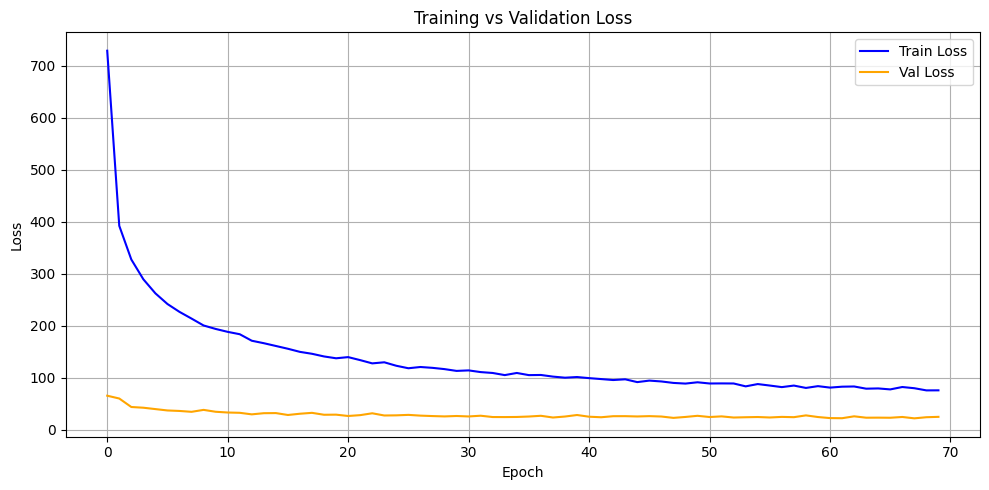

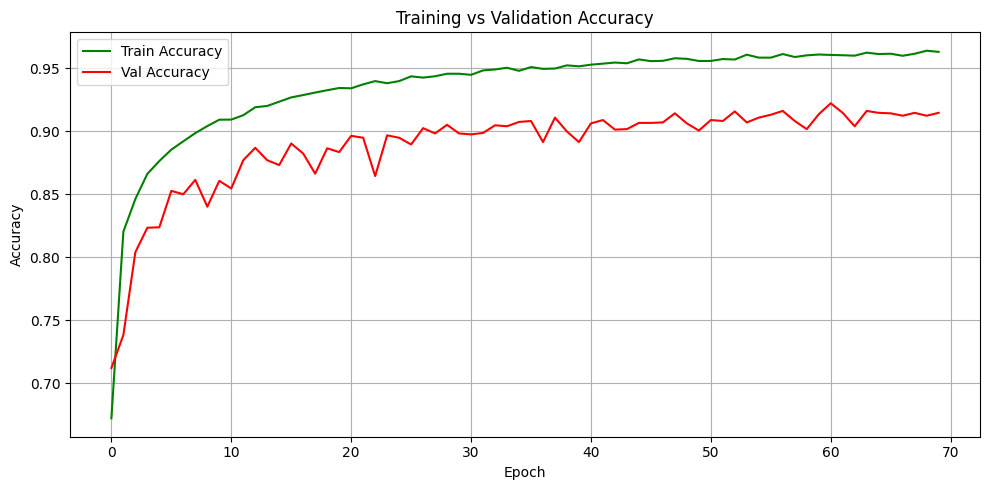

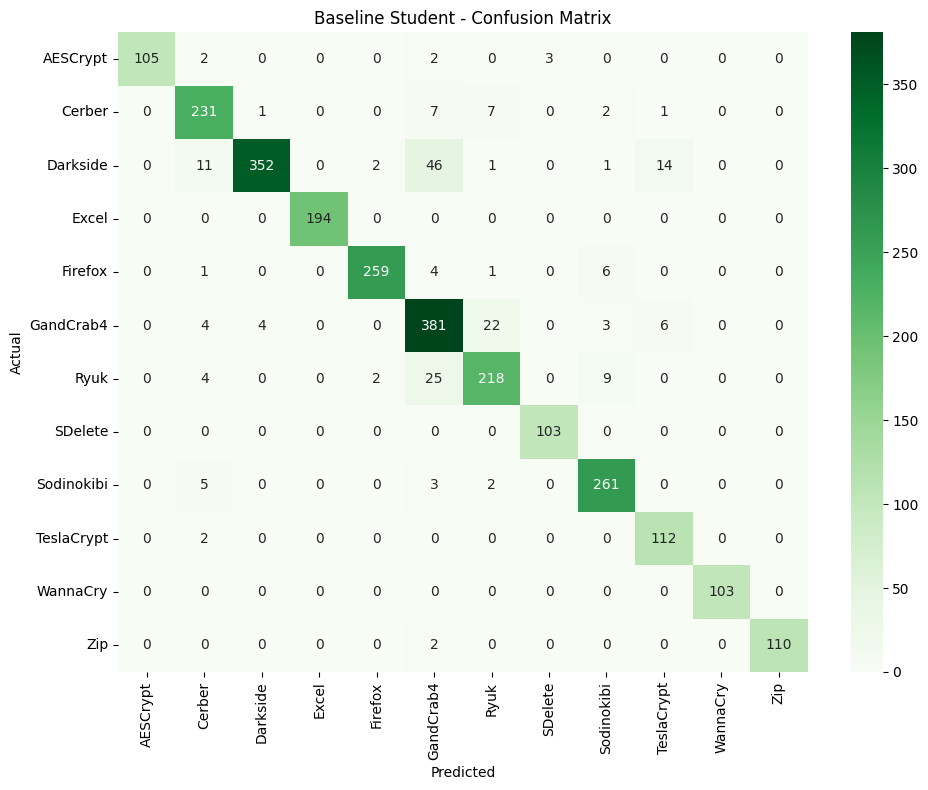


📋 Baseline Classification Report (Student, No KD):

              precision    recall  f1-score   support

    AESCrypt       1.00      0.94      0.97       112
      Cerber       0.89      0.93      0.91       249
    Darkside       0.99      0.82      0.90       427
       Excel       1.00      1.00      1.00       194
     Firefox       0.98      0.96      0.97       271
   GandCrab4       0.81      0.91      0.86       420
        Ryuk       0.87      0.84      0.86       258
     SDelete       0.97      1.00      0.99       103
  Sodinokibi       0.93      0.96      0.94       271
  TeslaCrypt       0.84      0.98      0.91       114
    WannaCry       1.00      1.00      1.00       103
         Zip       1.00      0.98      0.99       112

    accuracy                           0.92      2634
   macro avg       0.94      0.94      0.94      2634
weighted avg       0.93      0.92      0.92      2634

✅ Final Training Accuracy (baseline): 0.9629
✅ Final Validation Accuracy (baseli

In [ ]:

student_baseline.eval()
final_preds_b, final_labels_b = [], []
with torch.no_grad():
    for streams, labels in val_loader:
        streams = [s.to(device) for s in streams]
        labels = labels.to(device)
        outputs = student_baseline(streams)
        preds = torch.argmax(outputs, dim=1)
        final_preds_b.extend(preds.cpu().numpy())
        final_labels_b.extend(labels.cpu().numpy())
# === Plot
plot_loss_curve(train_losses_b, val_losses_b)
plot_accuracy_curve(train_accs_b, val_accs_b)
# Confusion matrix
cm_b = confusion_matrix(final_labels_b, final_preds_b)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_b, annot=True, fmt='d', cmap='Greens',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Baseline Student - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Report
print("\n📋 Baseline Classification Report (Student, No KD):\n")
print(classification_report(final_labels_b, final_preds_b, target_names=label_encoder.classes_))
print(f"✅ Final Training Accuracy (baseline): {train_accs_b[-1]:.4f}")
print(f"✅ Final Validation Accuracy (baseline): {val_accs_b[-1]:.4f}")


In [ ]:
expected_shape = (CHUNK_SIZE, NUM_FEATURES)
X_test, y_test = load_split_from_folder(os.path.join(INPUT_DIR, "test"), expected_shape)
y_test_str = y_test

test_dataset = MultiStreamDataset(X_test, y_test_str, label_encoder, augment=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)


/tmp/ipykernel_3245880/952631451.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_student_baseline.pth"))


=== 🧪 Final Test Set Classification Report ===
              precision    recall  f1-score   support

    AESCrypt     1.0000    0.9732    0.9864       112
      Cerber     0.9833    0.9592    0.9711       245
    Darkside     0.9793    0.8873    0.9310       426
       Excel     1.0000    0.9799    0.9899       249
     Firefox     0.9771    0.9771    0.9771       262
   GandCrab4     0.8252    0.9085    0.8648       426
        Ryuk     0.8689    0.8657    0.8673       268
     SDelete     0.9911    1.0000    0.9955       111
  Sodinokibi     0.8989    0.8889    0.8939       270
  TeslaCrypt     0.8205    0.8707    0.8449       147
    WannaCry     0.9697    1.0000    0.9846       128
         Zip     0.9825    0.9912    0.9868       113

    accuracy                         0.9285      2757
   macro avg     0.9414    0.9418    0.9411      2757
weighted avg     0.9314    0.9285    0.9292      2757



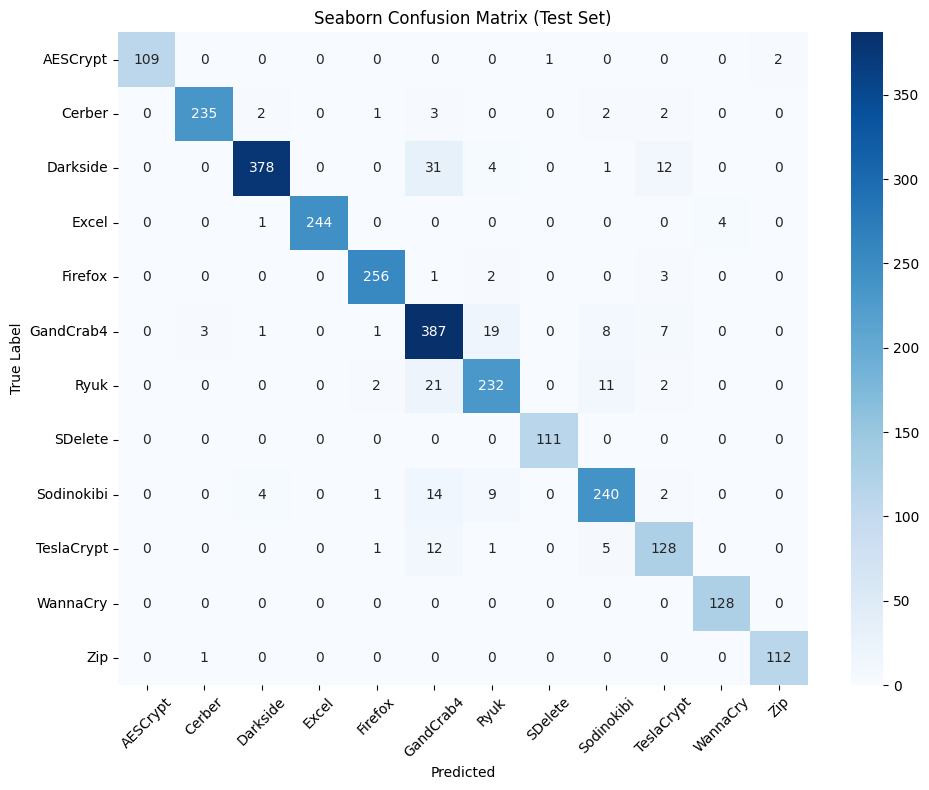

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Rebuild same model architecture
model = StudentCNN(input_length=CHUNK_SIZE, num_classes=len(label_encoder.classes_))
model.load_state_dict(torch.load("best_student_baseline.pth"))
model.to(device)
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for streams, labels in test_loader:
        # Move to device
        streams = [s.to(device) for s in streams]
        labels = labels.to(device)

        outputs = model(streams)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Inverse-transform for reporting
pred_labels_str = label_encoder.inverse_transform(all_preds)
true_labels_str = label_encoder.inverse_transform(all_labels)

# === 5. Classification Report
print("=== 🧪 Final Test Set Classification Report ===")
print(classification_report(true_labels_str, pred_labels_str, digits=4))

# === 6. Seaborn Confusion Matrix
cm = confusion_matrix(true_labels_str, pred_labels_str, labels=label_encoder.classes_)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("True Label")
plt.title("Seaborn Confusion Matrix (Test Set)")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Lightweight Measure student

In [ ]:
# import torch
# import torch.nn as nn
# import time
# import os
# import psutil
# import copy
# from thop import profile

# # === Profiling functions using clean model copies ===
# def get_stream_macs_params(stream):
#     dummy_input = torch.randn(1, 1, CHUNK_SIZE)
#     stream_copy = copy.deepcopy(stream)
#     macs, params = profile(stream_copy, inputs=(dummy_input,), verbose=False)
#     return macs, params

# def get_linear_macs_params(layer, in_features):
#     dummy_input = torch.randn(1, in_features)
#     layer_copy = copy.deepcopy(layer)
#     macs, params = profile(layer_copy, inputs=(dummy_input,), verbose=False)
#     return macs, params

# # === Utility functions ===
# def get_model_size(model):
#     temp_path = "temp_model.pth"
#     torch.save(model.state_dict(), temp_path)
#     size_mb = os.path.getsize(temp_path) / (1024 ** 2)
#     os.remove(temp_path)
#     return size_mb

# def measure_latency(model, inputs, n_runs=100):
#     model.eval()
#     with torch.no_grad():
#         start = time.time()
#         for _ in range(n_runs):
#             model(inputs)
#         end = time.time()
#     return (end - start) / n_runs * 1000

# def measure_cpu_usage(model, inputs, duration=2):
#     model.eval()
#     process = psutil.Process(os.getpid())
#     num_cpus = psutil.cpu_count(logical=True)
#     _ = process.cpu_percent(interval=None)
#     with torch.no_grad():
#         start_time = time.time()
#         while time.time() - start_time < duration:
#             model(inputs)
#     total_cpu_percent = process.cpu_percent(interval=None)
#     return total_cpu_percent / num_cpus

# # === Final evaluation logic ===
# def evaluate_full_model(model_class, model_path, *args, **kwargs):
#     # 🔁 Create two fresh instances using passed args
#     prof_model = model_class(*args, **kwargs)
#     prof_model.load_state_dict(torch.load(model_path))
#     prof_model.eval()

#     clean_model = model_class(*args, **kwargs)
#     clean_model.load_state_dict(torch.load(model_path))
#     clean_model.eval()

#     total_macs, total_params = 0, 0

#     # 🔍 Stream MACs
#     print("🔍 Stream MAC breakdown:")
#     for i in range(8):
#         macs_i, params_i = get_stream_macs_params(prof_model.streams[i])
#         print(f"  Stream[{i}] MACs: {macs_i}, Params: {params_i}")
#         total_macs += macs_i
#         total_params += params_i

#     # 🔍 FC layers
#     print("\n🔍 FC Layer breakdown:")
#     macs_fc1, params_fc1 = get_linear_macs_params(prof_model.fc[0], in_features=64)
#     print(f"  FC[0] (64→128) MACs: {macs_fc1}, Params: {params_fc1}")
#     macs_fc2, params_fc2 = get_linear_macs_params(prof_model.fc[4], in_features=128)
#     print(f"  FC[4] (128→classes) MACs: {macs_fc2}, Params: {params_fc2}")
#     total_macs += macs_fc1 + macs_fc2
#     total_params += params_fc1 + params_fc2

#     # 🔍 Projection
#     print("\n🔍 Projection Layer:")
#     macs_proj, params_proj = get_linear_macs_params(prof_model.proj, in_features=64)
#     print(f"  Proj (64→128) MACs: {macs_proj}, Params: {params_proj}")
#     total_macs += macs_proj
#     total_params += params_proj


#     flops = 2 * total_macs
#     size_mb = get_model_size(clean_model)

#     dummy_inputs = [torch.randn(1, 1, CHUNK_SIZE) for _ in range(8)]
#     latency = measure_latency(clean_model, dummy_inputs)
#     cpu_usage = measure_cpu_usage(clean_model, dummy_inputs)

#     return {
#         "Model Size (MB)": round(size_mb, 4),
#         "Latency (ms)": round(latency, 3),
#         "CPU Usage (%)": round(cpu_usage, 2),
#         "Total MACs": int(total_macs),
#         "FLOPs": int(flops),
#         "Total Params": int(total_params)
#     }


# # === Usage ===
# # You must define your StudentCNN class and load the model first
# model = StudentCNN(input_length=CHUNK_SIZE, num_classes=len(label_encoder.classes_))
# model.load_state_dict(torch.load("best_student_baseline.pth"))
# # Then:
# #torch.save(model.state_dict(), "student_model.pth")
# stats = evaluate_full_model(StudentCNN, "best_student_baseline.pth", input_length=CHUNK_SIZE, num_classes=len(label_encoder.classes_))
# for k, v in stats.items():
#     print(f"{k}: {v}")


/tmp/ipykernel_3245880/3242020110.py:109: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_student_baseline.pth"))
/tmp/ipykernel_3245880

🔍 Stream MAC breakdown:
  Stream[0] MACs: 1864.0, Params: 120.0
  Stream[1] MACs: 1864.0, Params: 120.0
  Stream[2] MACs: 1864.0, Params: 120.0
  Stream[3] MACs: 1864.0, Params: 120.0
  Stream[4] MACs: 1864.0, Params: 120.0
  Stream[5] MACs: 1864.0, Params: 120.0
  Stream[6] MACs: 1864.0, Params: 120.0
  Stream[7] MACs: 1864.0, Params: 120.0

🔍 FC Layer breakdown:
  FC[0] (64→128) MACs: 8192.0, Params: 0
  FC[4] (128→classes) MACs: 1536.0, Params: 0

🔍 Projection Layer:
  Proj (64→128) MACs: 8192.0, Params: 0
Model Size (MB): 0.0867
Latency (ms): 2.31
CPU Usage (%): 35.61
Total MACs: 32832
FLOPs: 65664
Total Params: 960


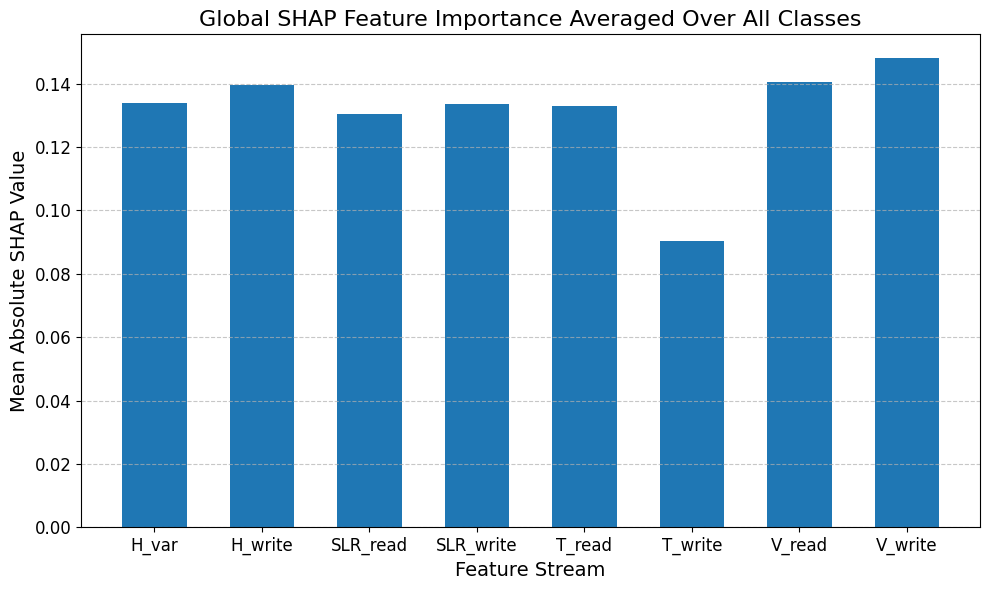

✅ Saved global SHAP bar plot as PNG and PDF.


In [ ]:
# import shap
# import torch
# import torch.nn as nn
# import numpy as np
# import matplotlib.pyplot as plt
# import pandas as pd

# # ===== 1. Load model =====
# model.eval()
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# # ===== 2. Load data batch =====
# streams, labels = next(iter(test_loader))
# sample_batch = [s.to(device) for s in streams]

# def batch_to_shap_input(batch):
#     return torch.cat(batch, dim=1)

# shap_input_full = batch_to_shap_input(sample_batch)  # [B,8,T]
# shap_input_full.requires_grad = True

# # ===== 3. Sample 100 examples randomly =====
# torch.manual_seed(42)
# np.random.seed(42)

# N = shap_input_full.shape[0]
# indices = np.random.choice(N, size=100)
# background_idx = indices[:30]
# test_idx = indices[30:]

# background = shap_input_full[background_idx]
# test_samples = shap_input_full[test_idx]

# # ===== 4. Wrapped model (return full logits) =====
# class MultiOutputWrapper(nn.Module):
#     def __init__(self, model):
#         super().__init__()
#         self.model = model

#     def forward(self, x):
#         split = [x[:, i:i+1, :] for i in range(x.size(1))]  # List of 8 [B,1,T]
#         return self.model(split)  # [B, num_classes]

# wrapped_model = MultiOutputWrapper(model).to(device)
# wrapped_model.eval()

# # ===== 5. Run GradientExplainer for all outputs =====
# explainer = shap.GradientExplainer(wrapped_model, background)
# shap_values = explainer.shap_values(test_samples)  # List of [B_test, 8, T] × num_classes

# # ===== 6. Global average over all classes =====
# num_classes = len(shap_values)
# num_streams = len(shap_values[0])  # Should be 8
# avg_importance = []

# for i in range(num_streams):
#     stream_total = 0.0
#     for c in range(num_classes):
#         stream_shap = shap_values[c][:, i, :]  # [B, T]
#         stream_total += np.abs(stream_shap).mean()
#     avg_importance.append(stream_total / num_classes)

# # ===== 7. Plot + Save Figure =====
# stream_names = ["T_write", "T_read", "V_write", "V_read", "H_write", "H_var", "SLR_write", "SLR_read"]

# # Sort and plot
# importance_df = pd.DataFrame({'Feature': stream_names, 'Importance': avg_importance})
# importance_df = importance_df.sort_values('Feature')  # Force fixed order

# plt.figure(figsize=(10, 6))
# plt.bar(importance_df['Feature'], importance_df['Importance'], width=0.6)
# plt.grid(axis='y', linestyle='--', alpha=0.7)
# plt.xticks(fontsize=12)
# plt.yticks(fontsize=12)
# plt.ylabel("Mean Absolute SHAP Value", fontsize=14)
# plt.xlabel("Feature Stream", fontsize=14)
# plt.title("Global SHAP Feature Importance Averaged Over All Classes", fontsize=16)
# plt.tight_layout()

# plt.savefig("global_avg_shap_per_stream.png", dpi=300)
# plt.savefig("global_avg_shap_per_stream.pdf")
# plt.show()

# print("✅ Saved global SHAP bar plot as PNG and PDF.")


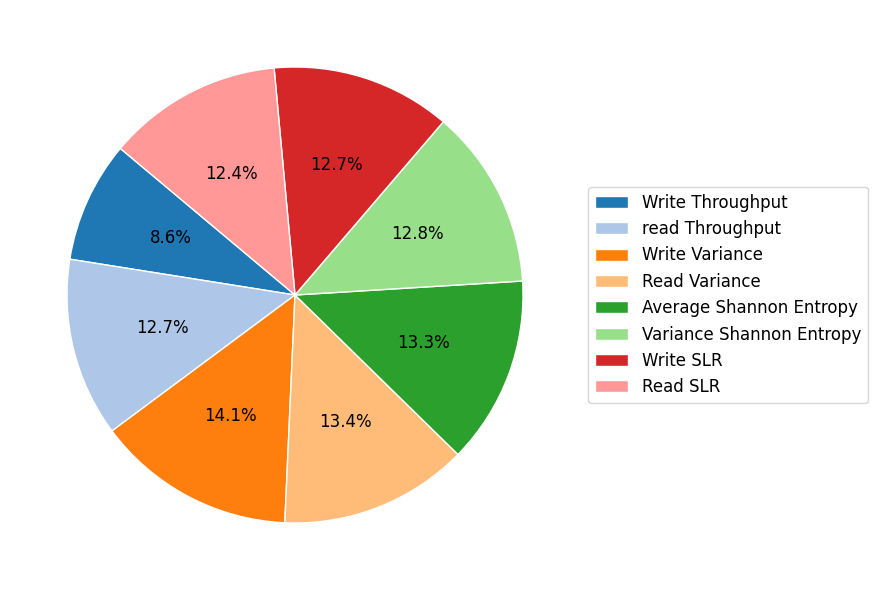

✅ Pie chart with external legend saved as PNG and PDF.


In [ ]:
# import matplotlib.pyplot as plt

# # ===== Pie Chart of SHAP Importance with External Legend =====
# plt.figure(figsize=(10, 6))
# stream_names = ["Write Throughput", "read Throughput", "Write Variance", "Read Variance", "Average Shannon Entropy", "Variance Shannon Entropy",
#                  "Write SLR", "Read SLR"]

# # Sort and plot
# importance_df = pd.DataFrame({'Feature': stream_names, 'Importance': avg_importance})
# # Keep original order based on stream_names
# importance_df = pd.DataFrame({'Feature': stream_names, 'Importance': avg_importance})
# colors = plt.cm.tab20.colors  # or any color palette you prefer

# # Create pie chart without labels
# wedges, texts, autotexts = plt.pie(
#     importance_df['Importance'], 
#     autopct='%1.1f%%',
#     startangle=140,
#     colors=colors[:len(importance_df)],
#     textprops={'fontsize': 12},
#     wedgeprops={'edgecolor': 'white'}
# )

# # Add legend outside the pie
# plt.legend(
#     wedges, 
#     importance_df['Feature'], 
#     # title="Feature Streams",
#     loc="center left",
#     bbox_to_anchor=(1, 0.5),
#     fontsize=12,
#     title_fontsize=14
# )

# # plt.title('Global SHAP Feature Importance per Stream', fontsize=16)
# plt.tight_layout()

# # Save the plot
# plt.savefig("global_avg_shap_pie_with_legend.png", dpi=300, bbox_inches="tight")
# plt.savefig("global_avg_shap_pie_with_legend.pdf", bbox_inches="tight")
# plt.show()

# print("✅ Pie chart with external legend saved as PNG and PDF.")



shap_values_stack.shape: (12, 70, 8, 16)
shap_values_avg_time.shape: (12, 70, 8)
shap_vals_flat.shape: (70, 8)
features_flat.shape: (70, 8)


/tmp/ipykernel_3245880/1431495212.py:24: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


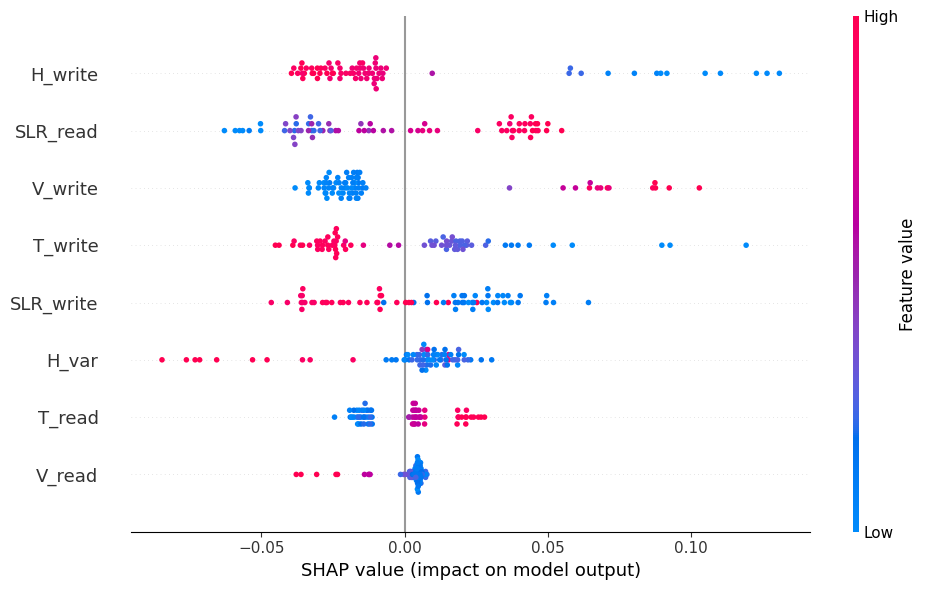

In [ ]:
# # ===== 0. First fix shap_values =====
# # shap_values: [70, 8, 51, 12]
# shap_values_split = [shap_values[..., i] for i in range(12)]  # List of 12 arrays [70, 8, 51]

# # ===== 1. Stack over classes =====
# shap_values_stack = np.stack(shap_values_split, axis=0)  # [12, 70, 8, 51]
# print("shap_values_stack.shape:", shap_values_stack.shape)  # Should now be (12, 70, 8, 51)

# # ===== 2. Average over time (axis=3)
# shap_values_avg_time = shap_values_stack.mean(axis=3)  # [12, 70, 8]
# print("shap_values_avg_time.shape:", shap_values_avg_time.shape)  # (12, 70, 8)

# # ===== 3. Average over classes (axis=0)
# shap_vals_flat = shap_values_avg_time.mean(axis=0)  # [70, 8]
# print("shap_vals_flat.shape:", shap_vals_flat.shape)  # ✅ (70, 8)

# # ===== 4. Feature values (inputs)
# features_flat = test_samples.detach().cpu().numpy().mean(axis=2)  # [70, 8]
# print("features_flat.shape:", features_flat.shape)  # ✅ (70, 8)

# # ===== 5. Plot
# stream_names = ["T_write", "T_read", "V_write", "V_read", "H_write", "H_var", "SLR_write", "SLR_read"]

# shap.summary_plot(
#     shap_vals_flat,
#     features_flat,
#     feature_names=stream_names,
#     plot_type="dot",
#     max_display=8,
#     show=False
# )

# plt.gcf().set_size_inches(10, 6)
# plt.tight_layout()
# plt.savefig("shap_beeswarm_streams.png", dpi=300, bbox_inches="tight")
# plt.savefig("shap_beeswarm_streams.pdf", bbox_inches="tight")
# plt.show()


In [44]:
import os
import torch
import pandas as pd
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import DataLoader

# === CONFIGURATION ===
detection_times = [30, 45, 60]
window_sizes = [10, 15, 20]
NUM_FEATURES = 8
BATCH_SIZE = 32
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

base_dir = "/home/HardDisk/Satang/thesis_proj/"
base_teacher_dir = os.path.join(base_dir, "Deep_Learning", "cnn", "teacher")
student_kd_dir = os.path.join(base_dir, "Deep_Learning", "cnn", "student")
student_baseline_dir = os.path.join(base_dir, "Deep_Learning", "cnn", "baseline_student")
csv_output_path = os.path.join(base_dir, "Deep_Learning", "cnn", "results", "model_eval_summary.csv")
os.makedirs(os.path.dirname(csv_output_path), exist_ok=True)

results = []

# === Evaluation Function ===
def evaluate_and_log(model, model_path, test_loader, label_encoder, T_d, T_w, model_type, input_type, results_list):
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model.to(DEVICE)
    model.eval()

    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            labels = labels.to(DEVICE)

            if input_type == "2d":
                inputs = inputs.to(DEVICE)
            elif input_type == "1d":
                inputs = [s.to(DEVICE) for s in inputs]
            else:
                raise ValueError("Invalid input_type")

            outputs = model(inputs)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    report = classification_report(all_labels, all_preds, target_names=label_encoder.classes_, output_dict=True)
    acc = accuracy_score(all_labels, all_preds)

    results_list.append({
        "Td": T_d,
        "Tw": T_w,
        "T_len": T_d - T_w + 1,
        "Model": model_type,
        "Accuracy": round(acc, 4),
        "Precision_macro": round(report["macro avg"]["precision"], 4),
        "Recall_macro": round(report["macro avg"]["recall"], 4),
        "F1_macro": round(report["macro avg"]["f1-score"], 4),
        "F1_weighted": round(report["weighted avg"]["f1-score"], 4),
    })

# === MAIN LOOP ===
for T_d in detection_times:
    for T_w in window_sizes:
        T_len = T_d - T_w + 1
        expected_shape = (T_len, NUM_FEATURES)
        folder_name = f"X_csv_split_{T_len}"
        test_path = os.path.join(base_dir, f"New_{T_d}", f"{T_w}", "split_tws", folder_name, "test")

        # === Load Raw Data and Encode
        X_test_raw, y_test_raw = load_split_from_folder(test_path, expected_shape)
        label_encoder = LabelEncoder()
        label_encoder.fit(y_test_raw)

        test_dataset_2d = SingleStream2DDataset(X_test_raw, y_test_raw, label_encoder, augment=False)
        test_loader_2d = DataLoader(test_dataset_2d, batch_size=BATCH_SIZE, shuffle=False)

        teacher_path = os.path.join(base_teacher_dir, f"cnn2d_Td{T_d}_Tw{T_w}.pth")
        teacher_model = SingleStreamCNN2D(num_classes=len(label_encoder.classes_))
        evaluate_and_log(teacher_model, teacher_path, test_loader_2d, label_encoder, T_d, T_w, "Teacher", "2d", results)


        test_dataset_1d = MultiStreamDataset(X_test_raw, y_test_raw, label_encoder, augment=False)
        test_loader_1d = DataLoader(test_dataset_1d, batch_size=BATCH_SIZE, shuffle=False)

        # === Student KD
        student_kd_path = os.path.join(student_kd_dir, f"student_KD_Td{T_d}_Tw{T_w}.pth")
        student_kd_model = StudentCNN(input_length=T_len, num_classes=len(label_encoder.classes_))
        evaluate_and_log(student_kd_model, student_kd_path, test_loader_1d, label_encoder, T_d, T_w, "Student_KD", "1d", results)

        # === Student Baseline
        student_baseline_path = os.path.join(student_baseline_dir, f"student_baseline_Td{T_d}_Tw{T_w}.pth")
        student_baseline_model = StudentCNN(input_length=T_len, num_classes=len(label_encoder.classes_))
        evaluate_and_log(student_baseline_model, student_baseline_path, test_loader_1d, label_encoder, T_d, T_w, "Student_Baseline", "1d", results)

# === Save Results
df_results = pd.DataFrame(results)
df_results.to_csv(csv_output_path, index=False)
print(f"\n✅ All evaluation results saved to: {csv_output_path}")


/tmp/ipykernel_1375046/415441803.py:26: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=DEVICE))
/tmp/ipykernel_13750


✅ All evaluation results saved to: /home/HardDisk/Satang/thesis_proj/Deep_Learning/cnn/results/model_eval_summary.csv


/tmp/ipykernel_1375046/415441803.py:26: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=DEVICE))


In [24]:
import os
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import DataLoader


# === CONFIG ===
base_dir = "/home/HardDisk/Satang/thesis_proj/"
teacher_dir = os.path.join(base_dir, "Deep_Learning", "multi_cnn", "teacher")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_FEATURES = 8
BATCH_SIZE = 64
detection_times = [30, 45, 60]
window_sizes = [10, 15, 20]

conf_matrix_dict = {}

# === Load and Evaluate ===
for T_d in detection_times:
    for T_w in window_sizes:
        T_len = T_d - T_w + 1
        test_csv_path = os.path.join(base_dir, f"New_{T_d}", f"{T_w}", "split_tws", f"X_csv_split_{T_len}", "test")

        X_test, y_test = load_split_from_folder(test_csv_path, expected_shape=(T_len, NUM_FEATURES))
        label_encoder = LabelEncoder()
        y_test_encoded = label_encoder.fit_transform(y_test)

        test_dataset = MultiStreamDataset(X_test, y_test, label_encoder, augment=False)
        test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

        model_path = os.path.join(teacher_dir, f"teacher_Td{T_d}_Tw{T_w}.pth")
        model = MultiStreamCNN(input_length=T_len, num_classes=len(label_encoder.classes_))
        model.load_state_dict(torch.load(model_path, map_location=DEVICE))
        model.to(DEVICE)
        model.eval()

        all_preds, all_labels = [], []
        with torch.no_grad():
            for streams, labels in test_loader:
                streams = [s.to(DEVICE) for s in streams]
                outputs = model(streams)
                preds = outputs.argmax(dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        cm = confusion_matrix(all_labels, all_preds)
        conf_matrix_dict[(T_d, T_w)] = (cm, label_encoder.classes_)

# === Plot Beautiful Seaborn Grid ===
fig, axes = plt.subplots(3, 3, figsize=(18, 18))
fig.suptitle("Teacher Model Confusion Matrices", fontsize=24)

for i, Td in enumerate(detection_times):
    for j, Tw in enumerate(window_sizes):
        ax = axes[i, j]
        cm, class_names = conf_matrix_dict[(Td, Tw)]
        sns.heatmap(
            cm, annot=True, fmt='d', cmap='Blues', cbar=True, ax=ax,
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 9}
        )
        ax.set_title(f"T_d={Td}, T_w={Tw}", fontsize=14)
        ax.tick_params(axis='x', labelrotation=45)
        ax.tick_params(axis='y', labelrotation=0)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig("teacher_confusion_matrices_beautiful.pdf", format="pdf", bbox_inches="tight", dpi=300)
plt.show()


NameError: name 'MultiStreamCNN' is not defined

In [ ]:
import os
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import DataLoader

# === CONFIG ===
base_dir = "/home/HardDisk/Satang/thesis_proj/"
student_dirs = {
    "Student": os.path.join(base_dir, "Deep_Learning", "multi_cnn", "baseline_student"),
    "Student_KD": os.path.join(base_dir, "Deep_Learning", "multi_cnn", "student")
}
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_FEATURES = 8
BATCH_SIZE = 64
detection_times = [30, 45, 60]
window_sizes = [10, 15, 20]

# === EVALUATE & PLOT FUNCTION ===
def evaluate_and_plot(model_name, model_dir, output_pdf):
    conf_matrix_dict = {}

    for T_d in detection_times:
        for T_w in window_sizes:
            T_len = T_d - T_w + 1
            test_csv_path = os.path.join(base_dir, f"New_{T_d}", f"{T_w}", "split_tws", f"X_csv_split_{T_len}", "test")

            X_test, y_test = load_split_from_folder(test_csv_path, expected_shape=(T_len, NUM_FEATURES))
            label_encoder = LabelEncoder()
            y_test_encoded = label_encoder.fit_transform(y_test)

            test_dataset = MultiStreamDataset(X_test, y_test, label_encoder, augment=False)
            test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

            if model_name == "Student":
                model_prefix = "student_baseline"
            elif model_name == "Student_KD":
                model_prefix = "student_KD"
            else:
                raise ValueError("Unknown model name")

            model_path = os.path.join(model_dir, f"{model_prefix}_Td{T_d}_Tw{T_w}.pth")
            model = StudentCNN(input_length=T_len, num_classes=len(label_encoder.classes_))
            model.load_state_dict(torch.load(model_path, map_location=DEVICE))
            model.to(DEVICE)
            model.eval()

            all_preds, all_labels = [], []
            with torch.no_grad():
                for streams, labels in test_loader:
                    streams = [s.to(DEVICE) for s in streams]
                    outputs = model(streams)
                    preds = outputs.argmax(dim=1)
                    all_preds.extend(preds.cpu().numpy())
                    all_labels.extend(labels.cpu().numpy())

            cm = confusion_matrix(all_labels, all_preds)
            conf_matrix_dict[(T_d, T_w)] = (cm, label_encoder.classes_)

    # === Plot 3x3 ===
    fig, axes = plt.subplots(3, 3, figsize=(18, 18))
    fig.suptitle(f"{model_name} Model Confusion Matrices", fontsize=24)

    for i, Td in enumerate(detection_times):
        for j, Tw in enumerate(window_sizes):
            ax = axes[i, j]
            cm, class_names = conf_matrix_dict[(Td, Tw)]
            sns.heatmap(
                cm, annot=True, fmt='d', cmap='Blues', cbar=True, ax=ax,
                xticklabels=class_names, yticklabels=class_names,
                annot_kws={"size": 9}
            )
            ax.set_title(f"T_d={Td}, T_w={Tw}", fontsize=14)
            ax.tick_params(axis='x', labelrotation=45)
            ax.tick_params(axis='y', labelrotation=0)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(output_pdf, format="pdf", bbox_inches="tight", dpi=300)
    plt.close()
    print(f"[✓] Saved {model_name} confusion matrix to {output_pdf}")

# === Run for both student models ===
evaluate_and_plot("Student", student_dirs["Student"], "student_confusion_matrices_beautiful.pdf")
evaluate_and_plot("Student_KD", student_dirs["Student_KD"], "student_kd_confusion_matrices_beautiful.pdf")


/tmp/ipykernel_2377727/1402582378.py:47: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=DEVICE))
/tmp/ipykernel_2377

[✓] Saved Student confusion matrix to student_confusion_matrices_beautiful.pdf


/tmp/ipykernel_2377727/1402582378.py:47: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=DEVICE))
/tmp/ipykernel_2377

[✓] Saved Student_KD confusion matrix to student_kd_confusion_matrices_beautiful.pdf
